# NB07 - Metadata-assisted image-audio Doppler hemodynamic feature demo

## Purpose

This notebook demonstrates a focused proof of concept for extracting structured Doppler hemodynamic proxy features from selected pulsed-wave Doppler ultrasound recordings.

The notebook uses two signal sources from the linked AVI export:

* the displayed PW Doppler spectrum as the image source
* the Doppler audio stream as an independent timing-support source

The native Mindray export is used as metadata support for automatic setup of:

* PW spectral ROI
* baseline / zero-velocity position
* time scale per pixel
* velocity scale per pixel

The demonstrated processing path is:

* Mindray native metadata and linked PW Doppler AVI are loaded.
* Metadata defines the spectral Doppler ROI, baseline, time scale, and velocity scale.
* The displayed Doppler spectrum is converted into a candidate velocity envelope.
* Candidate systolic peaks are detected from the calibrated velocity envelope.
* Beat-level Doppler proxy features are calculated from complete candidate beats.
* Doppler audio is extracted from the same linked AVI.
* Audio-derived beat timing is compared with image-derived beat timing.
* Beat-level, recording-level, and image-audio timing summaries are produced.

The notebook is a technical feasibility demo. It is not a clinical-grade Doppler measurement pipeline, native-file-only decoder, or diagnostic tool.


## Interpretation boundary

The extracted signal is treated as a candidate Doppler spectral envelope derived from the displayed PW Doppler video frame.

The resulting values are signal-processing proxy features. They are useful for technical discussion and feasibility demonstration, but they are not yet clinically validated Doppler measurements.

This notebook does not estimate:

```text
absolute volumetric blood flow
stroke volume
blood pressure
clinical diagnosis
clinical-grade Doppler parameters

##  Imports and Setup 

In [1]:
from pathlib import Path
import cv2, json, subprocess
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.signal import medfilt, savgol_filter, find_peaks, spectrogram

In [2]:
# Project paths

NATIVE_BATCH_DIR = Path(r"D:\code\DopplerLab\ultrasound_recordings\batch_2026_06_13_native")

SELECTED_RECORDING_IDS = [
    "202606130411060002SMP",
    "202606130420260005SMP"
]

## Metadata-assisted setup

The notebook reads native Mindray metadata from `DcmRegionPara.txt`.

For the PW Doppler spectral region, this metadata can provide:

```text
spectral ROI display coordinates
baseline / zero-velocity reference position
time scale per horizontal pixel
velocity scale per vertical pixel

In [3]:
def read_mindray_text_file(file_path, encodings=("utf-8", "utf-16", "latin-1")):
    """
    Read a Mindray native text-like file using several possible encodings.

    Native export files may be regular UTF-8 text, XML, UTF-16 text,
    or simple ASCII-compatible files. The function tries several common
    encodings and returns the decoded text plus the encoding that worked.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to a readable Mindray native file.

    encodings : tuple of str
        Encodings to try, in order.

    Returns
    -------
    text : str or None
        Decoded file content if reading succeeds.

    used_encoding : str or None
        Encoding that successfully decoded the file.

    error : str or None
        None if reading succeeds. Otherwise, a short error message.
    """

    file_path = Path(file_path)

    if not file_path.exists():
        return None, None, f"File does not exist: {file_path}"

    for encoding in encodings:
        try:
            text = file_path.read_text(encoding=encoding)
            return text, encoding, None
        except UnicodeDecodeError:
            continue
        except Exception as exc:
            return None, None, str(exc)

    return None, None, "Could not decode with tested encodings"

In [4]:
def parse_mindray_data_tree_text(text):
    """
    Parse a Mindray DATA_TREE text file into a long key-value table.

    Mindray native text files often use nested DATA_TREE blocks. The function
    tracks the current tree path and stores every key-value line together
    with that path.

    Parameters
    ----------
    text : str
        Raw decoded text from a Mindray DATA_TREE file.

    Returns
    -------
    pandas.DataFrame
        Long table with one row per parsed key-value line.

        Columns:
        - tree_path
        - depth
        - key
        - value_raw
        - line_number
        - line_raw
    """
    rows = []
    path_stack = []
    lines = text.splitlines()

    for line_number, line_raw in enumerate(lines, start=1):
        stripped = line_raw.strip()

        if stripped == "":
            continue

        if stripped.startswith("DATA_TREE_BEGIN="):
            node_name = stripped.split("=", 1)[1].strip()
            path_stack.append(node_name)
            continue

        if stripped.startswith("DATA_TREE_END="):
            node_name = stripped.split("=", 1)[1].strip()

            if len(path_stack) == 0:
                rows.append(
                    {
                        "tree_path": "",
                        "depth": 0,
                        "key": "__PARSER_WARNING__",
                        "value_raw": f"Unexpected DATA_TREE_END={node_name}",
                        "line_number": line_number,
                        "line_raw": line_raw,
                    }
                )
                continue

            last_node = path_stack[-1]

            if last_node != node_name:
                rows.append(
                    {
                        "tree_path": "/".join(path_stack),
                        "depth": len(path_stack),
                        "key": "__PARSER_WARNING__",
                        "value_raw": f"Mismatched end. Expected {last_node}, got {node_name}",
                        "line_number": line_number,
                        "line_raw": line_raw,
                    }
                )

            path_stack.pop()
            continue

        if "=" in stripped:
            key, value_raw = stripped.split("=", 1)

            rows.append(
                {
                    "tree_path": "/".join(path_stack),
                    "depth": len(path_stack),
                    "key": key.strip(),
                    "value_raw": value_raw.strip(),
                    "line_number": line_number,
                    "line_raw": line_raw,
                }
            )
            continue

        rows.append(
            {
                "tree_path": "/".join(path_stack),
                "depth": len(path_stack),
                "key": "__UNPARSED_LINE__",
                "value_raw": stripped,
                "line_number": line_number,
                "line_raw": line_raw,
            }
        )

    if len(path_stack) > 0:
        rows.append(
            {
                "tree_path": "/".join(path_stack),
                "depth": len(path_stack),
                "key": "__PARSER_WARNING__",
                "value_raw": f"Unclosed tree path: {'/'.join(path_stack)}",
                "line_number": len(lines),
                "line_raw": "",
            }
        )

    return pd.DataFrame(rows)

In [5]:
def parse_mindray_readable_tree_files(native_batch_dir, selected_recording_ids=None):
    """
    Parse readable Mindray DATA_TREE files across selected native recordings.

    The function reads native text files that use the DATA_TREE format.
    It intentionally skips XML files such as app.xml because XML should be
    parsed separately if needed.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    selected_recording_ids : list of str or None
        Recording IDs to parse. If None, all recording folders in the batch
        directory are parsed.

    Returns
    -------
    pandas.DataFrame
        Long table with parsed DATA_TREE key-value metadata.
    """

    native_batch_dir = Path(native_batch_dir)

    tree_file_names = [
        "DcmRegionPara.txt",
        "BackEndSystem.txt",
        "BackEndSystemInfo.txt",
        "VirtualMachine.txt",
    ]

    if selected_recording_ids is None:
        recording_dirs = sorted([path for path in native_batch_dir.iterdir() if path.is_dir()])
    else:
        recording_dirs = [native_batch_dir / recording_id for recording_id in selected_recording_ids]

    rows = []

    for recording_dir in recording_dirs:
        recording_id = recording_dir.name
        native_dir = recording_dir / "native"

        if not native_dir.exists():
            rows.append(
                {
                    "recording_id": recording_id,
                    "file_name": "__NATIVE_DIR__",
                    "used_encoding": None,
                    "tree_path": "",
                    "depth": 0,
                    "key": "__READ_ERROR__",
                    "value_raw": f"Native directory does not exist: {native_dir}",
                    "line_number": np.nan,
                    "line_raw": "",
                }
            )
            continue

        for file_name in tree_file_names:
            file_path = native_dir / file_name

            if not file_path.exists():
                continue

            text, used_encoding, error = read_mindray_text_file(file_path)

            if error is not None:
                rows.append(
                    {
                        "recording_id": recording_id,
                        "file_name": file_name,
                        "used_encoding": used_encoding,
                        "tree_path": "",
                        "depth": 0,
                        "key": "__READ_ERROR__",
                        "value_raw": error,
                        "line_number": np.nan,
                        "line_raw": "",
                    }
                )
                continue

            parsed_df = parse_mindray_data_tree_text(text)
            parsed_df.insert(0, "used_encoding", used_encoding)
            parsed_df.insert(0, "file_name", file_name)
            parsed_df.insert(0, "recording_id", recording_id)

            rows.append(parsed_df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)

In [6]:
def build_dcm_region_summary(parsed_tree_df):
    """
    Build a structured region summary from parsed DcmRegionPara.txt rows.

    DcmRegionPara.txt describes displayed ultrasound regions. The function
    converts the long parsed key-value table into a wide table where each row
    represents one recording and one DcmRegion.

    Parameters
    ----------
    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table produced by parse_mindray_readable_tree_files().

    Returns
    -------
    pandas.DataFrame
        Structured region summary with geometry and physical calibration fields.
    """
    if parsed_tree_df.empty:
        return pd.DataFrame()

    dcm_df = parsed_tree_df[parsed_tree_df["file_name"] == "DcmRegionPara.txt"].copy()
    region_df = dcm_df[dcm_df["tree_path"].str.contains(r"DcmRegionInfo/DcmRegion\d+$", regex=True, na=False)].copy()

    if len(region_df) == 0:
        return pd.DataFrame()

    region_df["region_name"] = region_df["tree_path"].str.extract(r"(DcmRegion\d+)$")

    wide_df = (
        region_df
        .pivot_table(
            index=["recording_id", "region_name"],
            columns="key",
            values="value_raw",
            aggfunc="first",
        )
        .reset_index()
    )

    wide_df.columns.name = None

    numeric_columns = [
        "DataType",
        "Flags",
        "PhyDeltaX",
        "PhyDeltaY",
        "PhyUnitsX",
        "PhyUnitsY",
        "PhyValueVirX",
        "PhyValueVirY",
        "SpatialFormat",
        "VirRefAvail",
        "VirX",
        "VirY",
        "X0",
        "X1",
        "Y0",
        "Y1",
        "bColorFlag",
        "bContrastImgInUse",
    ]

    for column in numeric_columns:
        if column in wide_df.columns:
            wide_df[column] = pd.to_numeric(wide_df[column], errors="coerce")

    if {"X0", "X1"}.issubset(wide_df.columns):
        wide_df["width_px"] = wide_df["X1"] - wide_df["X0"]

    if {"Y0", "Y1"}.issubset(wide_df.columns):
        wide_df["height_px"] = wide_df["Y1"] - wide_df["Y0"]

    if {"width_px", "PhyDeltaX"}.issubset(wide_df.columns):
        wide_df["physical_width"] = wide_df["width_px"] * wide_df["PhyDeltaX"]

    if {"height_px", "PhyDeltaY"}.issubset(wide_df.columns):
        wide_df["physical_height"] = wide_df["height_px"] * wide_df["PhyDeltaY"]

    return wide_df.sort_values(["recording_id", "region_name"]).reset_index(drop=True)

In [7]:
def classify_dcm_region_roles(dcm_region_summary_df):
    """
    Assign exploratory roles to Mindray DcmRegion rows.

    The function does not assume that a fixed region index always contains
    the same content. Instead, it classifies each region using metadata fields
    such as data type, spatial format, physical units, and physical deltas.

    Parameters
    ----------
    dcm_region_summary_df : pandas.DataFrame
        Structured DcmRegion summary table.

    Returns
    -------
    pandas.DataFrame
        Copy of the input table with region role columns.
    """
    classified_df = dcm_region_summary_df.copy()

    roles = []
    reasons = []

    for _, row in classified_df.iterrows():
        data_type = row.get("DataType")
        spatial_format = row.get("SpatialFormat")
        phy_units_x = row.get("PhyUnitsX")
        phy_units_y = row.get("PhyUnitsY")
        phy_delta_x = row.get("PhyDeltaX")
        phy_delta_y = row.get("PhyDeltaY")
        y0 = row.get("Y0")
        y1 = row.get("Y1")

        is_pw_like = (
            data_type == 3
            and spatial_format == 3
            and phy_units_x == 4
            and phy_units_y == 7
            and pd.notna(phy_delta_x)
            and pd.notna(phy_delta_y)
            and abs(float(phy_delta_x) - 0.006) < 0.001
            and float(phy_delta_y) < 0
        )

        is_anatomical_like = (
            data_type == 1
            and spatial_format == 1
            and phy_units_x == 3
            and phy_units_y == 3
            and pd.notna(phy_delta_x)
            and pd.notna(phy_delta_y)
            and float(phy_delta_x) > 0
            and float(phy_delta_y) > 0
        )

        if is_pw_like:
            roles.append("pw_spectral_region")
            reasons.append("DataType=3, SpatialFormat=3, units X=4/Y=7, PhyDeltaX is near 0.006, and PhyDeltaY is negative.")
        elif is_anatomical_like:
            roles.append("anatomical_image_region")
            reasons.append("DataType=1, SpatialFormat=1, units X=3/Y=3, and both physical deltas are positive.")
        elif pd.notna(y0) and pd.notna(y1) and y0 >= 230 and y1 >= 500:
            roles.append("possible_pw_display_region")
            reasons.append("Display coordinates are in the lower Doppler-panel area, but metadata fields did not fully match the PW rule.")
        elif pd.notna(y0) and pd.notna(y1) and y0 < 230 and y1 <= 230:
            roles.append("possible_anatomical_display_region")
            reasons.append("Display coordinates are in the upper image-panel area, but metadata fields did not fully match the anatomical rule.")
        else:
            roles.append("unknown_region")
            reasons.append("No exploratory rule matched this region.")

    classified_df["region_role"] = roles
    classified_df["region_role_reason"] = reasons
    classified_df["is_pw_spectral_region"] = classified_df["region_role"] == "pw_spectral_region"
    classified_df["is_anatomical_image_region"] = classified_df["region_role"] == "anatomical_image_region"

    return classified_df

In [8]:
def inspect_linked_avi_metadata(native_batch_dir, recording_id):
    """
    Inspect linked AVI metadata for one Mindray native recording folder.

    The linked AVI is treated as the image signal source for NB07.
    The native metadata is used only to support setup and calibration.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing recording folders.

    recording_id : str
        Mindray recording folder ID.

    Returns
    -------
    dict
        Basic AVI metadata including path, FPS, frame count, duration,
        width, and height.
    """
    native_batch_dir = Path(native_batch_dir)
    linked_avi_dir = native_batch_dir / recording_id / "linked_avi"

    if not linked_avi_dir.exists():
        raise FileNotFoundError(f"linked_avi directory does not exist: {linked_avi_dir}")

    avi_files = sorted(linked_avi_dir.glob("*.avi"))

    if len(avi_files) == 0:
        raise FileNotFoundError(f"No AVI files found in: {linked_avi_dir}")
    if len(avi_files) > 1:
        print(f"Warning: multiple AVI files found. Using first file: {avi_files[0]}")

    avi_path = avi_files[0]
    cap = cv2.VideoCapture(str(avi_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open AVI file: {avi_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    duration_s = frame_count / fps if fps > 0 else np.nan

    return {
        "recording_id": recording_id,
        "avi_path": avi_path,
        "fps": fps,
        "frame_count": frame_count,
        "duration_s": duration_s,
        "video_width_px": width,
        "video_height_px": height,
    }

In [9]:
def build_metadata_assisted_pw_config_table(native_batch_dir, selected_recording_ids):
    """
    Build a metadata-assisted PW Doppler configuration table.

    The function parses DcmRegionPara.txt for selected native recordings,
    identifies the PW spectral region, and converts native metadata fields
    into explicit extraction parameters for linked AVI processing.

    The resulting configuration table is intended to remove manual setup
    for spectral ROI, baseline, time scale, and velocity scale.

    Parameters
    ----------
    native_batch_dir : str or pathlib.Path
        Batch directory containing Mindray native recording folders.

    selected_recording_ids : list of str
        Recording IDs to include in the NB07 demo.

    Returns
    -------
    config_df : pandas.DataFrame
        One row per selected recording with ROI, baseline, calibration,
        and linked AVI metadata.

    parsed_tree_df : pandas.DataFrame
        Long parsed metadata table.

    dcm_region_classified_df : pandas.DataFrame
        Classified DcmRegion table used to build the configuration.
    """
    native_batch_dir = Path(native_batch_dir)
    parsed_tree_df = parse_mindray_readable_tree_files(native_batch_dir=native_batch_dir, selected_recording_ids=selected_recording_ids)

    dcm_region_summary_df = build_dcm_region_summary(parsed_tree_df)
    dcm_region_classified_df = classify_dcm_region_roles(dcm_region_summary_df)

    pw_region_df = dcm_region_classified_df[dcm_region_classified_df["is_pw_spectral_region"]].copy()

    if len(pw_region_df) == 0:
        raise ValueError("No PW spectral region was identified from DcmRegionPara.txt.")

    missing_recording_ids = sorted(set(selected_recording_ids) - set(pw_region_df["recording_id"]))

    if len(missing_recording_ids) > 0:
        raise ValueError("No PW spectral region was identified for these recordings:\n" + "\n".join(missing_recording_ids))

    duplicate_counts = pw_region_df["recording_id"].value_counts()
    duplicate_recording_ids = duplicate_counts[duplicate_counts > 1].index.tolist()

    if len(duplicate_recording_ids) > 0:
        raise ValueError("More than one PW spectral region was identified for these recordings:\n" + "\n".join(duplicate_recording_ids))

    config_rows = []

    for _, row in pw_region_df.iterrows():
        recording_id = row["recording_id"]

        avi_metadata = inspect_linked_avi_metadata(native_batch_dir=native_batch_dir, recording_id=recording_id,)

        x_min = int(row["X0"])
        x_max = int(row["X1"])
        y_min = int(row["Y0"])
        y_max = int(row["Y1"])

        baseline_y_roi_px = float(row["VirY"])
        baseline_y_global_px = float(row["Y0"] + row["VirY"])

        seconds_per_px = abs(float(row["PhyDeltaX"]))
        cm_s_per_px = abs(float(row["PhyDeltaY"]))

        width_px = int(row["width_px"])
        height_px = int(row["height_px"])

        sweep_duration_s = width_px * seconds_per_px
        velocity_span_cm_s = height_px * cm_s_per_px

        config_rows.append(
            {
                "recording_id": recording_id,
                "region_name": row["region_name"],
                "avi_path": avi_metadata["avi_path"],
                "fps": avi_metadata["fps"],
                "frame_count": avi_metadata["frame_count"],
                "duration_s": avi_metadata["duration_s"],
                "video_width_px": avi_metadata["video_width_px"],
                "video_height_px": avi_metadata["video_height_px"],
                "x_min": x_min,
                "x_max": x_max,
                "y_min": y_min,
                "y_max": y_max,
                "width_px": width_px,
                "height_px": height_px,
                "baseline_y_roi_px": baseline_y_roi_px,
                "baseline_y_global_px": baseline_y_global_px,
                "seconds_per_px": seconds_per_px,
                "cm_s_per_px": cm_s_per_px,
                "sweep_duration_s": sweep_duration_s,
                "velocity_span_cm_s": velocity_span_cm_s,
                "PhyDeltaX": float(row["PhyDeltaX"]),
                "PhyDeltaY": float(row["PhyDeltaY"]),
                "PhyUnitsX": row["PhyUnitsX"],
                "PhyUnitsY": row["PhyUnitsY"],
                "region_role_reason": row["region_role_reason"],
            }
        )

    config_df = pd.DataFrame(config_rows)
    config_df = config_df.sort_values("recording_id").reset_index(drop=True)

    return config_df, parsed_tree_df, dcm_region_classified_df

In [10]:
pw_config_df, parsed_tree_df, dcm_region_classified_df = build_metadata_assisted_pw_config_table(
    native_batch_dir=NATIVE_BATCH_DIR,
    selected_recording_ids=SELECTED_RECORDING_IDS,
)

display(
    pw_config_df[
        [
            "recording_id",
            "avi_path",
            "fps",
            "frame_count",
            "duration_s",
            "x_min",
            "x_max",
            "y_min",
            "y_max",
            "baseline_y_roi_px",
            "baseline_y_global_px",
            "seconds_per_px",
            "cm_s_per_px",
            "sweep_duration_s",
        ]
    ]
)

,recording_id,avi_path,fps,frame_count,duration_s,x_min,x_max,y_min,y_max,baseline_y_roi_px,baseline_y_global_px,seconds_per_px,cm_s_per_px,sweep_duration_s
0,202606130411060002SMP,D:\code\DopplerLab\ultrasound_recordings\batch...,30.0,1778,59.266667,79,659,245,508,131.0,376.0,0.006,0.176946,3.48
1,202606130420260005SMP,D:\code\DopplerLab\ultrasound_recordings\batch...,30.0,1367,45.566667,79,659,245,508,131.0,376.0,0.006,0.176946,3.48


## Source frame inspection

This section verifies whether the native metadata correctly maps onto the linked AVI video frame.

The PW Doppler spectral ROI and baseline are taken from `DcmRegionPara.txt`. The linked AVI is used only as the displayed image source.

This step is a visual sanity check before envelope extraction. If the ROI rectangle and baseline do not align with the displayed Doppler spectrum, downstream velocity and beat features should not be trusted.

In [11]:
def read_video_frame_at_time(video_path, time_s=None, frame_index=None, convert_to_rgb=True, fallback_search_radius=5):
    """
    Read one frame from a video file at a requested time or frame index.

    The function opens the video file with OpenCV, seeks to the requested
    frame, and returns the decoded frame together with basic frame metadata.
    A small fallback search is used if the exact requested frame cannot be
    decoded.

    Parameters
    ----------
    video_path : str or pathlib.Path
        Path to the video file.

    time_s : float or None
        Requested time in seconds. This is used when frame_index is not
        provided.

    frame_index : int or None
        Requested frame index. If provided, this takes priority over time_s.

    convert_to_rgb : bool
        If True, the returned frame is converted from BGR to RGB for
        matplotlib display.

    fallback_search_radius : int
        Number of nearby frames to try if the requested frame cannot be read.

    Returns
    -------
    frame : numpy.ndarray
        Decoded video frame.

    frame_info : dict
        Metadata describing the frame read operation.
    """
    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(f"Video file does not exist: {video_path}")

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video file: {video_path}")

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width_px = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height_px = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if frame_count <= 0:
        cap.release()
        raise RuntimeError(f"Video file has no readable frames: {video_path}")

    if frame_index is None:
        if time_s is None:
            frame_index = frame_count // 2
            requested_time_s = frame_index / fps if fps > 0 else np.nan
        else:
            frame_index = int(round(float(time_s) * fps))
            requested_time_s = float(time_s)
    else:
        frame_index = int(frame_index)
        requested_time_s = frame_index / fps if fps > 0 else np.nan

    frame_index = int(np.clip(frame_index, 0, frame_count - 1))
    candidate_indices = [frame_index]

    for offset in range(1, fallback_search_radius + 1):
        candidate_indices.append(frame_index - offset)
        candidate_indices.append(frame_index + offset)

    candidate_indices = [int(idx) for idx in candidate_indices if 0 <= int(idx) < frame_count]

    frame = None
    actual_frame_index = None

    for candidate_index in candidate_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, candidate_index)
        ok, candidate_frame = cap.read()

        if ok and candidate_frame is not None:
            frame = candidate_frame
            actual_frame_index = candidate_index
            break

    cap.release()

    if frame is None:
        raise RuntimeError(f"Could not read requested frame or nearby fallback frames from: {video_path}")
    if convert_to_rgb:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    actual_time_s = actual_frame_index / fps if fps > 0 else np.nan

    frame_info = {
        "video_path": video_path,
        "fps": fps,
        "frame_count": frame_count,
        "width_px": width_px,
        "height_px": height_px,
        "requested_frame_index": frame_index,
        "actual_frame_index": actual_frame_index,
        "requested_time_s": requested_time_s,
        "actual_time_s": actual_time_s,
    }

    return frame, frame_info

In [12]:
def draw_metadata_roi_and_baseline_on_frame(
    frame_rgb,
    config_row,
    roi_color=(255, 0, 0),
    baseline_color=(255, 255, 0),
    roi_thickness=2,
    baseline_thickness=2,
):
    """
    Draw the metadata-derived PW spectral ROI and baseline on a video frame.

    The function overlays the ROI rectangle and zero-velocity baseline using
    coordinates from the metadata-assisted configuration table.

    Parameters
    ----------
    frame_rgb : numpy.ndarray
        RGB video frame.

    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    roi_color : tuple
        RGB color used for the ROI rectangle.

    baseline_color : tuple
        RGB color used for the baseline.

    roi_thickness : int
        Rectangle line thickness in pixels.

    baseline_thickness : int
        Baseline line thickness in pixels.

    Returns
    -------
    overlay_rgb : numpy.ndarray
        Copy of the input frame with ROI and baseline overlay.
    """
    overlay_rgb = frame_rgb.copy()

    x_min = int(config_row["x_min"])
    x_max = int(config_row["x_max"])
    y_min = int(config_row["y_min"])
    y_max = int(config_row["y_max"])
    baseline_y_global_px = int(round(float(config_row["baseline_y_global_px"])))

    cv2.rectangle(
        overlay_rgb,
        (x_min, y_min),
        (x_max, y_max),
        roi_color,
        roi_thickness,
    )

    cv2.line(
        overlay_rgb,
        (x_min, baseline_y_global_px),
        (x_max, baseline_y_global_px),
        baseline_color,
        baseline_thickness,
    )

    return overlay_rgb

In [13]:
def plot_source_frame_with_metadata_overlay(config_row, time_fraction=0.5, time_s=None, figsize=(12, 8)):
    """
    Plot one linked AVI frame with metadata-derived ROI and baseline overlay.

    The function reads a representative frame from the linked AVI, overlays
    the PW spectral ROI and baseline from DcmRegionPara.txt, and displays
    the result for visual sanity checking.

    Parameters
    ----------
    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    time_fraction : float
        Relative position in the video duration used when time_s is not
        provided. For example, 0.5 reads a frame near the middle.

    time_s : float or None
        Explicit video time in seconds. If provided, this takes priority
        over time_fraction.

    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    frame_rgb : numpy.ndarray
        Original RGB frame.

    overlay_rgb : numpy.ndarray
        RGB frame with ROI and baseline overlay.

    frame_info : dict
        Metadata about the frame read operation.
    """
    avi_path = Path(config_row["avi_path"])
    if time_s is None:
        duration_s = float(config_row["duration_s"])
        time_s = float(time_fraction) * duration_s

    frame_rgb, frame_info = read_video_frame_at_time(
        video_path=avi_path,
        time_s=time_s,
        convert_to_rgb=True,
    )
    overlay_rgb = draw_metadata_roi_and_baseline_on_frame(
        frame_rgb=frame_rgb,
        config_row=config_row,
    )
    recording_id = config_row["recording_id"]

    title = (
        f"{recording_id}\n"
        f"frame={frame_info['actual_frame_index']} | "
        f"time={frame_info['actual_time_s']:.2f} s | "
        f"ROI x={int(config_row['x_min'])}-{int(config_row['x_max'])}, "
        f"y={int(config_row['y_min'])}-{int(config_row['y_max'])} | "
        f"baseline y={float(config_row['baseline_y_global_px']):.1f}"
    )
    plt.figure(figsize=figsize)
    plt.imshow(overlay_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

    return frame_rgb, overlay_rgb, frame_info

In [14]:
def plot_metadata_overlay_samples(pw_config_df, time_fractions=(0.25, 0.5, 0.75), figsize=(12, 8)):
    """
    Plot metadata-derived ROI and baseline overlays for selected recordings.

    The function samples several time points from each linked AVI file.
    This helps verify that the metadata-derived ROI and baseline remain
    visually aligned with the displayed PW Doppler panel across the video.

    Parameters
    ----------
    pw_config_df : pandas.DataFrame
        Metadata-assisted PW configuration table.

    time_fractions : tuple of float
        Relative video positions to sample for each recording.

    figsize : tuple
        Matplotlib figure size for each displayed frame.

    Returns
    -------
    sample_info_df : pandas.DataFrame
        Table describing the displayed sample frames.
    """

    sample_rows = []

    for _, config_row in pw_config_df.iterrows():
        for time_fraction in time_fractions:
            frame_rgb, overlay_rgb, frame_info = plot_source_frame_with_metadata_overlay(
                config_row=config_row,
                time_fraction=time_fraction,
                figsize=figsize,
            )

            sample_rows.append(
                {
                    "recording_id": config_row["recording_id"],
                    "time_fraction": time_fraction,
                    "actual_time_s": frame_info["actual_time_s"],
                    "actual_frame_index": frame_info["actual_frame_index"],
                    "fps": frame_info["fps"],
                    "frame_count": frame_info["frame_count"],
                    "roi_x_min": int(config_row["x_min"]),
                    "roi_x_max": int(config_row["x_max"]),
                    "roi_y_min": int(config_row["y_min"]),
                    "roi_y_max": int(config_row["y_max"]),
                    "baseline_y_global_px": float(config_row["baseline_y_global_px"]),
                }
            )

    sample_info_df = pd.DataFrame(sample_rows)

    return sample_info_df

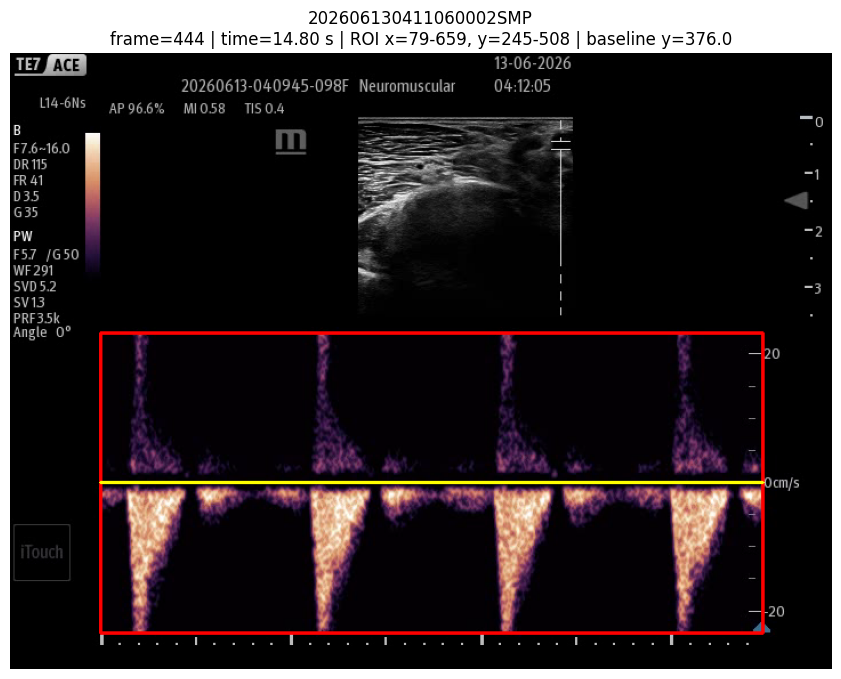

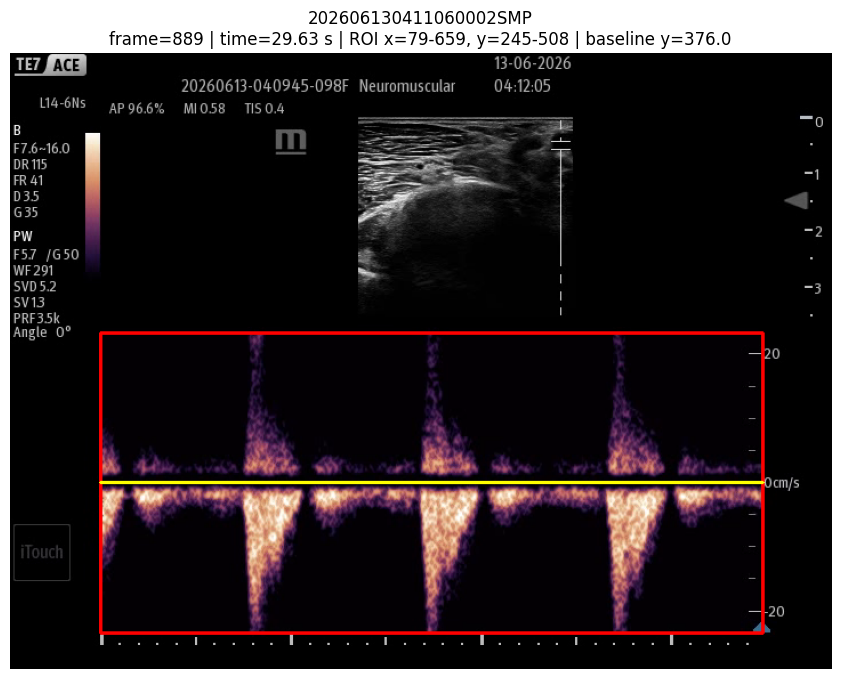

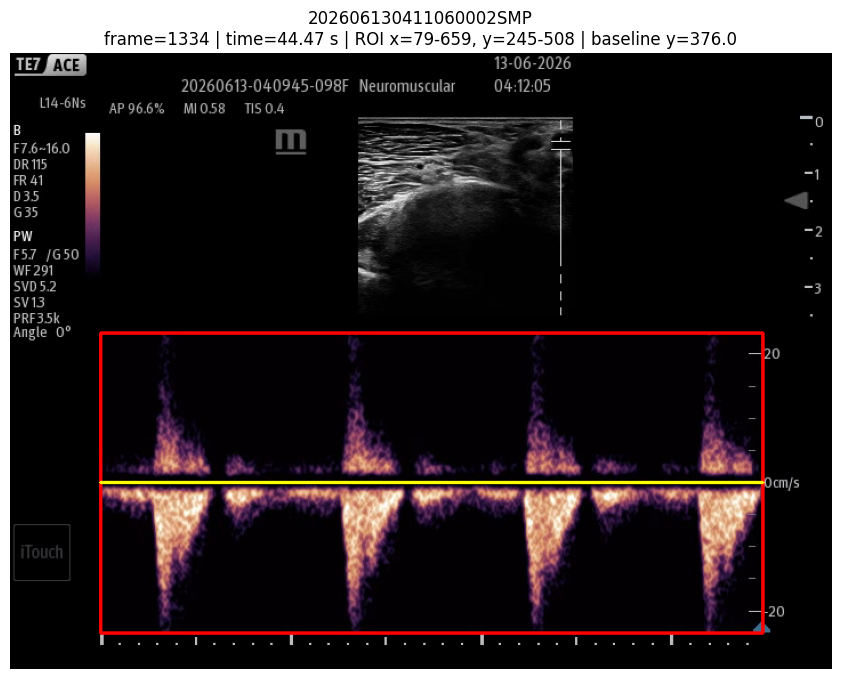

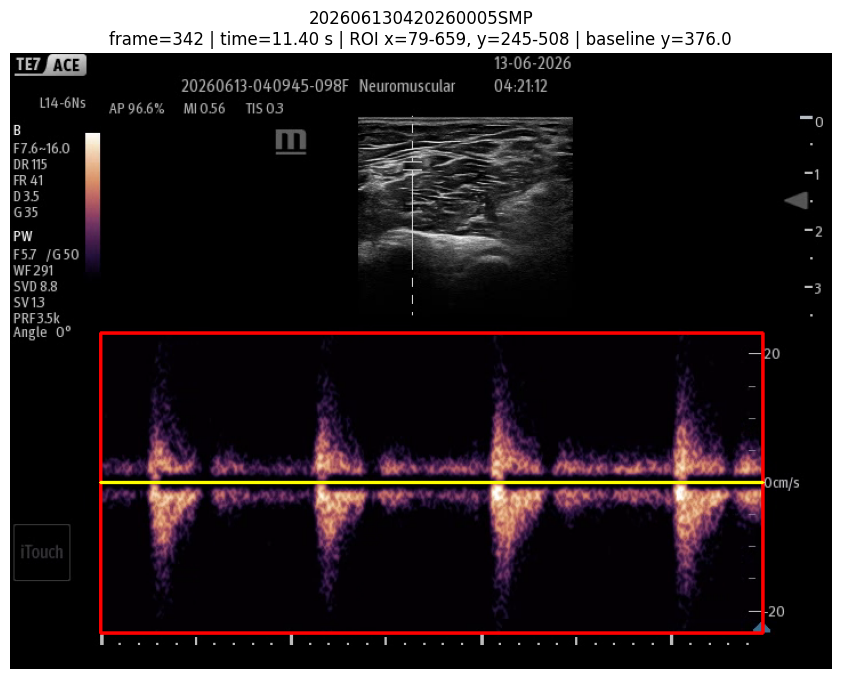

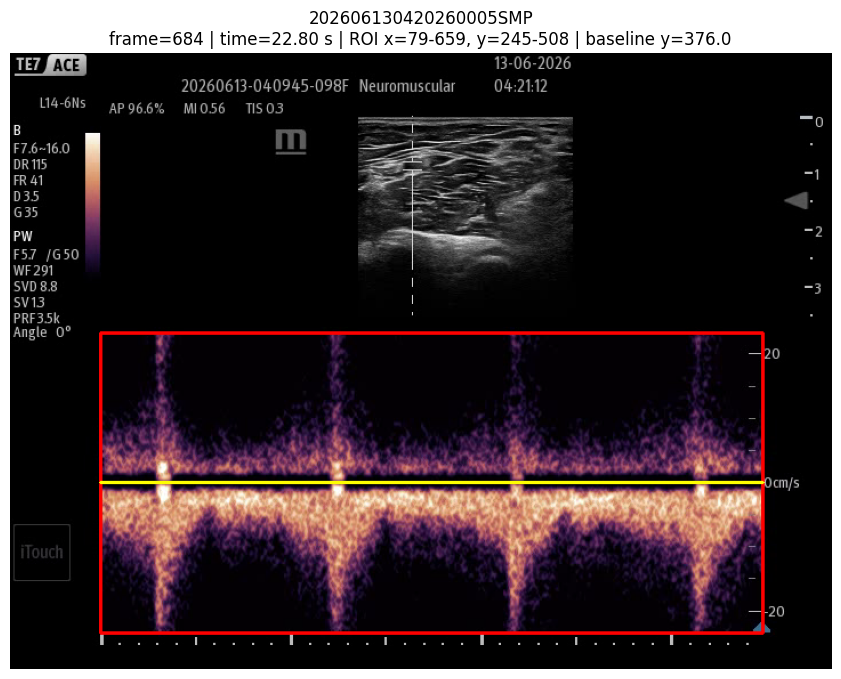

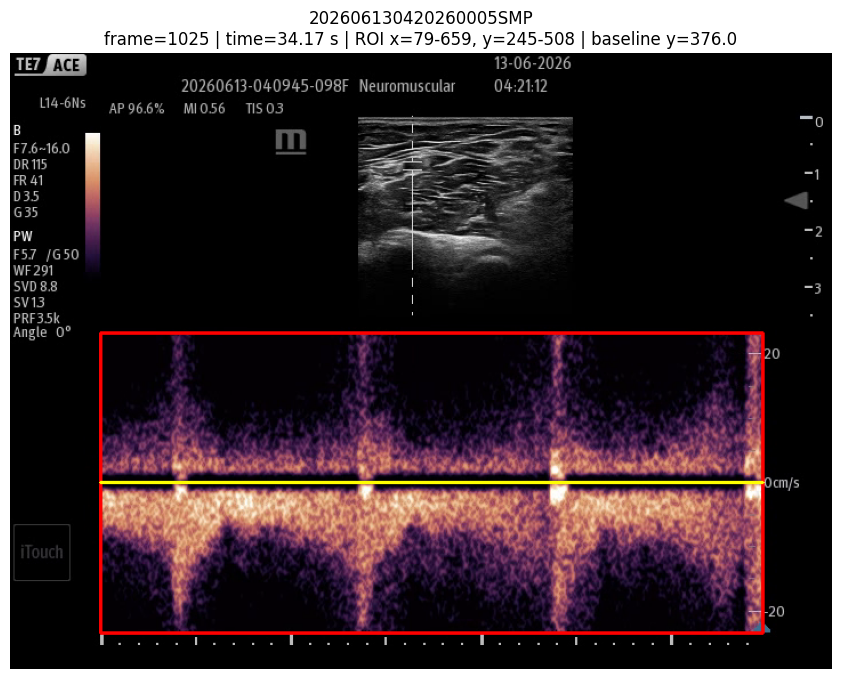

,recording_id,time_fraction,actual_time_s,actual_frame_index,fps,frame_count,roi_x_min,roi_x_max,roi_y_min,roi_y_max,baseline_y_global_px
0,202606130411060002SMP,0.25,14.800000,444,30.0,1778,79,659,245,508,376.0
1,202606130411060002SMP,0.50,29.633333,889,30.0,1778,79,659,245,508,376.0
2,202606130411060002SMP,0.75,44.466667,1334,30.0,1778,79,659,245,508,376.0
3,202606130420260005SMP,0.25,11.400000,342,30.0,1367,79,659,245,508,376.0
4,202606130420260005SMP,0.50,22.800000,684,30.0,1367,79,659,245,508,376.0
5,202606130420260005SMP,0.75,34.166667,1025,30.0,1367,79,659,245,508,376.0


In [15]:
metadata_overlay_sample_df = plot_metadata_overlay_samples(
    pw_config_df=pw_config_df,
    time_fractions=(0.25, 0.5, 0.75),
    figsize=(12, 8),
)

display(metadata_overlay_sample_df)

## Metadata-assisted envelope extraction

This section extracts a candidate Doppler velocity envelope from the metadata-defined PW spectral ROI.

The ROI, baseline, time scale, and velocity scale are taken from `DcmRegionPara.txt`.

The extraction uses the linked AVI frame as the image source. The extracted envelope is treated as a candidate spectral envelope from the displayed Doppler image, not as a validated clinical maximum velocity trace.

The dominant Doppler side is selected automatically by comparing spectral energy above and below the metadata-defined baseline.

In [16]:
def crop_metadata_spectral_roi(
    frame_rgb,
    config_row,
    left_margin_px=0,
    right_margin_px=20,
    top_margin_px=0,
    bottom_margin_px=0,
):
    """
    Crop the metadata-defined PW Doppler spectral ROI from one video frame.

    The function uses DcmRegionPara-derived display coordinates and applies
    small fixed margins to reduce contamination from axis labels or panel
    borders. The margins are display-cleanup parameters, not manual
    recording-specific ROI definitions.

    Parameters
    ----------
    frame_rgb : numpy.ndarray
        RGB video frame.

    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    left_margin_px : int
        Number of pixels removed from the left side of the metadata ROI.

    right_margin_px : int
        Number of pixels removed from the right side of the metadata ROI.

    top_margin_px : int
        Number of pixels removed from the top side of the metadata ROI.

    bottom_margin_px : int
        Number of pixels removed from the bottom side of the metadata ROI.

    Returns
    -------
    roi_rgb : numpy.ndarray
        Cropped RGB spectral ROI.

    roi_info : dict
        Geometry of the cropped ROI in both global and ROI coordinates.
    """
    frame_height, frame_width = frame_rgb.shape[:2]

    x_min_metadata = int(config_row["x_min"])
    x_max_metadata = int(config_row["x_max"])
    y_min_metadata = int(config_row["y_min"])
    y_max_metadata = int(config_row["y_max"])

    x_min = int(np.clip(x_min_metadata + left_margin_px, 0, frame_width - 1))
    x_max = int(np.clip(x_max_metadata - right_margin_px, x_min + 1, frame_width))
    y_min = int(np.clip(y_min_metadata + top_margin_px, 0, frame_height - 1))
    y_max = int(np.clip(y_max_metadata - bottom_margin_px, y_min + 1, frame_height))

    roi_rgb = frame_rgb[y_min:y_max, x_min:x_max].copy()

    baseline_y_global_px = float(config_row["baseline_y_global_px"])
    baseline_y_roi_px = baseline_y_global_px - y_min

    roi_info = {
        "x_min_global_px": x_min,
        "x_max_global_px": x_max,
        "y_min_global_px": y_min,
        "y_max_global_px": y_max,
        "width_px": x_max - x_min,
        "height_px": y_max - y_min,
        "baseline_y_global_px": baseline_y_global_px,
        "baseline_y_roi_px": baseline_y_roi_px,
        "left_margin_px": left_margin_px,
        "right_margin_px": right_margin_px,
        "top_margin_px": top_margin_px,
        "bottom_margin_px": bottom_margin_px,
    }

    return roi_rgb, roi_info

In [17]:
def build_spectral_foreground_mask(
    roi_rgb,
    value_threshold=35,
    saturation_threshold=25,
    gray_threshold=30,
    baseline_y_roi_px=None,
    baseline_exclusion_px=3,
):
    """
    Build a foreground mask for the displayed Doppler spectral signal.

    The function identifies non-background spectral pixels using a simple
    combination of intensity and saturation thresholds. A narrow band around
    the baseline can be excluded to reduce contamination from the displayed
    zero-velocity line.

    Parameters
    ----------
    roi_rgb : numpy.ndarray
        RGB spectral ROI.

    value_threshold : int
        Minimum HSV value channel threshold.

    saturation_threshold : int
        Minimum HSV saturation threshold.

    gray_threshold : int
        Minimum grayscale intensity threshold.

    baseline_y_roi_px : float or None
        Baseline position in ROI coordinates. If provided, a narrow baseline
        band is removed from the mask.

    baseline_exclusion_px : int
        Half-width of the excluded baseline band in pixels.

    Returns
    -------
    mask : numpy.ndarray
        Boolean foreground mask with shape matching the ROI height and width.

    mask_debug : dict
        Intermediate threshold images useful for diagnostics.
    """
    hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)

    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    color_foreground = (value >= value_threshold) & (saturation >= saturation_threshold)
    gray_foreground = gray >= gray_threshold

    mask = color_foreground | gray_foreground

    if baseline_y_roi_px is not None:
        baseline_y_roi_px = int(round(float(baseline_y_roi_px)))

        y0 = max(0, baseline_y_roi_px - baseline_exclusion_px)
        y1 = min(mask.shape[0], baseline_y_roi_px + baseline_exclusion_px + 1)

        mask[y0:y1, :] = False

    mask_debug = {
        "gray": gray,
        "saturation": saturation,
        "value": value,
        "color_foreground": color_foreground,
        "gray_foreground": gray_foreground,
    }

    return mask, mask_debug

In [18]:
def estimate_dominant_doppler_side(mask, baseline_y_roi_px, min_distance_from_baseline_px=4):
    """
    Estimate the dominant Doppler side relative to the baseline.

    The function compares distance-weighted foreground energy above and below
    the metadata-defined baseline. The side with larger weighted energy is
    treated as the dominant side for envelope extraction.

    Parameters
    ----------
    mask : numpy.ndarray
        Boolean spectral foreground mask with shape (height, width).

    baseline_y_roi_px : float
        Baseline position in ROI coordinates.

    min_distance_from_baseline_px : int
        Minimum distance from the baseline used for side-energy comparison.

    Returns
    -------
    dominant_side : str
        Either "above_baseline" or "below_baseline".

    side_summary : dict
        Distance-weighted energy summary for both sides.
    """
    mask = np.asarray(mask, dtype=bool)

    if mask.ndim != 2:
        raise ValueError("mask must be a 2D boolean array.")

    height, width = mask.shape

    baseline_y_roi_px = int(round(float(baseline_y_roi_px)))

    if baseline_y_roi_px < 0 or baseline_y_roi_px >= height:
        raise ValueError(f"baseline_y_roi_px={baseline_y_roi_px} is outside mask height={height}.")

    y_indices = np.arange(height, dtype=float)[:, None]
    distance_from_baseline = y_indices - float(baseline_y_roi_px)
    distance_from_baseline_full = np.broadcast_to(distance_from_baseline, mask.shape)

    above_mask = (mask & (distance_from_baseline_full <= -float(min_distance_from_baseline_px)))
    below_mask = (mask & (distance_from_baseline_full >= float(min_distance_from_baseline_px)))

    above_energy = float(np.sum(np.abs(distance_from_baseline_full[above_mask])))
    below_energy = float(np.sum(np.abs(distance_from_baseline_full[below_mask])))

    above_pixel_count = int(np.sum(above_mask))
    below_pixel_count = int(np.sum(below_mask))

    if below_energy >= above_energy:
        dominant_side = "below_baseline"
    else:
        dominant_side = "above_baseline"

    side_summary = {
        "above_energy": above_energy,
        "below_energy": below_energy,
        "above_pixel_count": above_pixel_count,
        "below_pixel_count": below_pixel_count,
        "dominant_side": dominant_side,
        "above_to_below_energy_ratio": above_energy / below_energy if below_energy > 0 else np.nan,
        "below_to_above_energy_ratio": below_energy / above_energy if above_energy > 0 else np.nan,
        "mask_height": height,
        "mask_width": width,
        "baseline_y_roi_px": baseline_y_roi_px,
    }

    return dominant_side, side_summary

In [19]:
def extract_envelope_from_mask(
    mask,
    baseline_y_roi_px,
    dominant_side,
    min_distance_from_baseline_px=3,
    min_column_pixels=1,
):
    """
    Extract a column-wise Doppler envelope from a foreground mask.

    For each x-position, the function finds the farthest foreground pixel
    from the baseline on the dominant Doppler side. This produces a candidate
    spectral envelope in ROI pixel coordinates.

    Parameters
    ----------
    mask : numpy.ndarray
        Boolean spectral foreground mask.

    baseline_y_roi_px : float
        Baseline position in ROI coordinates.

    dominant_side : str
        Doppler side used for extraction. Expected values are
        "above_baseline" or "below_baseline".

    min_distance_from_baseline_px : int
        Minimum distance from the baseline accepted as Doppler signal.

    min_column_pixels : int
        Minimum number of foreground pixels required in a column.

    Returns
    -------
    envelope_y_roi_px : numpy.ndarray
        Extracted envelope y-position for each x-column. Missing columns
        are represented as NaN.

    valid_column_mask : numpy.ndarray
        Boolean vector indicating columns with valid envelope estimates.
    """
    baseline_y_roi_px = float(baseline_y_roi_px)

    height, width = mask.shape
    envelope_y_roi_px = np.full(width, np.nan, dtype=float)
    valid_column_mask = np.zeros(width, dtype=bool)

    for x_idx in range(width):
        column_mask = mask[:, x_idx]

        if np.sum(column_mask) < min_column_pixels:
            continue

        y_positions = np.flatnonzero(column_mask)

        if dominant_side == "below_baseline":
            y_candidates = y_positions[y_positions >= baseline_y_roi_px + min_distance_from_baseline_px]

            if len(y_candidates) == 0:
                continue

            envelope_y_roi_px[x_idx] = float(np.max(y_candidates))
            valid_column_mask[x_idx] = True

        elif dominant_side == "above_baseline":
            y_candidates = y_positions[y_positions <= baseline_y_roi_px - min_distance_from_baseline_px]

            if len(y_candidates) == 0:
                continue

            envelope_y_roi_px[x_idx] = float(np.min(y_candidates))
            valid_column_mask[x_idx] = True

        else:
            raise ValueError("dominant_side must be 'above_baseline' or 'below_baseline'.")

    return envelope_y_roi_px, valid_column_mask

In [20]:
def interpolate_and_smooth_envelope(
    envelope_y_roi_px,
    median_kernel_size=5,
    savgol_window_length=21,
    savgol_polyorder=2,
):
    """
    Interpolate and smooth a raw column-wise Doppler envelope.

    The function fills missing envelope columns by linear interpolation and
    applies median and Savitzky-Golay smoothing. The smoothing is intended
    to reduce pixel-level noise while preserving the main beat morphology.

    Parameters
    ----------
    envelope_y_roi_px : numpy.ndarray
        Raw envelope y-position with NaN values for missing columns.

    median_kernel_size : int
        Odd kernel size for median filtering.

    savgol_window_length : int
        Odd window length for Savitzky-Golay smoothing.

    savgol_polyorder : int
        Polynomial order for Savitzky-Golay smoothing.

    Returns
    -------
    envelope_y_filled_px : numpy.ndarray
        Envelope after interpolation.

    envelope_y_smooth_px : numpy.ndarray
        Interpolated and smoothed envelope.

    interpolation_success : bool
        True if at least two valid points were available for interpolation.
    """
    envelope_y_roi_px = np.asarray(envelope_y_roi_px, dtype=float)
    x = np.arange(len(envelope_y_roi_px))
    valid_mask = np.isfinite(envelope_y_roi_px)

    if np.sum(valid_mask) < 2:
        envelope_y_filled_px = envelope_y_roi_px.copy()
        envelope_y_smooth_px = envelope_y_roi_px.copy()
        return envelope_y_filled_px, envelope_y_smooth_px, False

    envelope_y_filled_px = np.interp(x, x[valid_mask], envelope_y_roi_px[valid_mask])

    if median_kernel_size is not None and median_kernel_size >= 3:
        if median_kernel_size % 2 == 0:
            median_kernel_size += 1

        envelope_y_filled_px = medfilt(envelope_y_filled_px, kernel_size=median_kernel_size)

    envelope_y_smooth_px = envelope_y_filled_px.copy()

    if savgol_window_length is not None and savgol_window_length >= 5:
        if savgol_window_length % 2 == 0:
            savgol_window_length += 1

        if savgol_window_length < len(envelope_y_smooth_px):
            envelope_y_smooth_px = savgol_filter(
                envelope_y_smooth_px,
                window_length=savgol_window_length,
                polyorder=savgol_polyorder,
                mode="interp",
            )

    return envelope_y_filled_px, envelope_y_smooth_px, True

In [21]:
def extract_metadata_assisted_velocity_envelope_from_frame(
    frame_rgb,
    config_row,
    right_margin_px=20,
    baseline_exclusion_px=3,
    value_threshold=35,
    saturation_threshold=25,
    gray_threshold=30,
    min_distance_from_baseline_px=3,
):
    """
    Extract a metadata-assisted Doppler velocity envelope from one frame.

    The function crops the PW spectral ROI using native metadata, builds a
    spectral foreground mask, estimates the dominant Doppler side, extracts
    the farthest envelope from the baseline, and converts pixel distance into
    velocity using the metadata-derived velocity scale.

    Parameters
    ----------
    frame_rgb : numpy.ndarray
        RGB video frame.

    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    right_margin_px : int
        Fixed cleanup margin removed from the right side of the metadata ROI.

    baseline_exclusion_px : int
        Half-width of the excluded baseline band in pixels.

    value_threshold : int
        HSV value threshold for foreground masking.

    saturation_threshold : int
        HSV saturation threshold for foreground masking.

    gray_threshold : int
        Grayscale threshold for foreground masking.

    min_distance_from_baseline_px : int
        Minimum accepted distance from the baseline.

    Returns
    -------
    signal_df : pandas.DataFrame
        Time-aligned velocity envelope table.

    extraction_debug : dict
        Diagnostic objects and parameters used during extraction.
    """
    roi_rgb, roi_info = crop_metadata_spectral_roi(
        frame_rgb=frame_rgb,
        config_row=config_row,
        left_margin_px=0,
        right_margin_px=right_margin_px,
        top_margin_px=0,
        bottom_margin_px=0,
    )
    baseline_y_roi_px = roi_info["baseline_y_roi_px"]

    mask, mask_debug = build_spectral_foreground_mask(
        roi_rgb=roi_rgb,
        value_threshold=value_threshold,
        saturation_threshold=saturation_threshold,
        gray_threshold=gray_threshold,
        baseline_y_roi_px=baseline_y_roi_px,
        baseline_exclusion_px=baseline_exclusion_px,
    )

    dominant_side, side_summary = estimate_dominant_doppler_side(
        mask=mask,
        baseline_y_roi_px=baseline_y_roi_px,
        min_distance_from_baseline_px=min_distance_from_baseline_px,
    )

    envelope_y_raw_px, valid_column_mask = extract_envelope_from_mask(
        mask=mask,
        baseline_y_roi_px=baseline_y_roi_px,
        dominant_side=dominant_side,
        min_distance_from_baseline_px=min_distance_from_baseline_px,
    )

    envelope_y_filled_px, envelope_y_smooth_px, interpolation_success = interpolate_and_smooth_envelope(
        envelope_y_roi_px=envelope_y_raw_px,
        median_kernel_size=5,
        savgol_window_length=21,
        savgol_polyorder=2,
    )

    x_roi_px = np.arange(len(envelope_y_raw_px), dtype=float)
    seconds_per_px = float(config_row["seconds_per_px"])
    cm_s_per_px = float(config_row["cm_s_per_px"])
    time_s = x_roi_px * seconds_per_px

    if dominant_side == "below_baseline":
        distance_from_baseline_px = envelope_y_smooth_px - baseline_y_roi_px
        signed_velocity_cm_s = -distance_from_baseline_px * cm_s_per_px
    else:
        distance_from_baseline_px = baseline_y_roi_px - envelope_y_smooth_px
        signed_velocity_cm_s = distance_from_baseline_px * cm_s_per_px

    velocity_abs_cm_s = np.abs(signed_velocity_cm_s)

    signal_df = pd.DataFrame(
        {
            "x_roi_px": x_roi_px,
            "time_s": time_s,
            "envelope_y_raw_px": envelope_y_raw_px,
            "envelope_y_filled_px": envelope_y_filled_px,
            "envelope_y_smooth_px": envelope_y_smooth_px,
            "valid_column": valid_column_mask,
            "distance_from_baseline_px": distance_from_baseline_px,
            "velocity_signed_cm_s": signed_velocity_cm_s,
            "velocity_abs_cm_s": velocity_abs_cm_s,
        }
    )

    extraction_debug = {
        "roi_rgb": roi_rgb,
        "roi_info": roi_info,
        "mask": mask,
        "mask_debug": mask_debug,
        "dominant_side": dominant_side,
        "side_summary": side_summary,
        "interpolation_success": interpolation_success,
        "parameters": {
            "right_margin_px": right_margin_px,
            "baseline_exclusion_px": baseline_exclusion_px,
            "value_threshold": value_threshold,
            "saturation_threshold": saturation_threshold,
            "gray_threshold": gray_threshold,
            "min_distance_from_baseline_px": min_distance_from_baseline_px,
        },
    }

    return signal_df, extraction_debug

In [22]:
def plot_metadata_assisted_envelope_extraction(
    signal_df,
    extraction_debug,
    config_row,
    frame_info=None,
    figsize=(14, 10),
):
    """
    Plot diagnostics for metadata-assisted Doppler envelope extraction.

    The function displays the cropped ROI, foreground mask, and calibrated
    velocity-time envelope. This provides a visual check before beat detection
    and feature extraction are added.

    Parameters
    ----------
    signal_df : pandas.DataFrame
        Velocity envelope table returned by
        extract_metadata_assisted_velocity_envelope_from_frame().

    extraction_debug : dict
        Diagnostic dictionary returned by
        extract_metadata_assisted_velocity_envelope_from_frame().

    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    frame_info : dict or None
        Frame metadata from read_video_frame_at_time().

    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    None
        The function displays diagnostic plots.
    """
    roi_rgb = extraction_debug["roi_rgb"]
    mask = extraction_debug["mask"]
    roi_info = extraction_debug["roi_info"]
    dominant_side = extraction_debug["dominant_side"]
    side_summary = extraction_debug["side_summary"]

    baseline_y_roi_px = float(roi_info["baseline_y_roi_px"])

    title_suffix = ""

    if frame_info is not None:
        title_suffix = (f" | frame={frame_info['actual_frame_index']} | time={frame_info['actual_time_s']:.2f} s")

    recording_id = config_row["recording_id"]

    plt.figure(figsize=figsize)

    plt.subplot(3, 1, 1)
    plt.imshow(roi_rgb)
    plt.axhline(baseline_y_roi_px, color="yellow", linewidth=2)
    plt.plot(
        signal_df["x_roi_px"],
        signal_df["envelope_y_smooth_px"],
        linewidth=2,
    )
    plt.title(f"{recording_id} — spectral ROI with extracted envelope{title_suffix}\n dominant side: {dominant_side}")
    plt.axis("off")

    plt.subplot(3, 1, 2)
    plt.imshow(mask, cmap="gray", aspect="auto")
    plt.axhline(baseline_y_roi_px, color="yellow", linewidth=2)
    plt.title(
        "Foreground mask "
        f"| above energy={side_summary['above_energy']:.0f}, "
        f"below energy={side_summary['below_energy']:.0f}"
    )
    plt.xlabel("x [px]")
    plt.ylabel("y [px]")

    plt.subplot(3, 1, 3)
    plt.plot(
        signal_df["time_s"],
        signal_df["velocity_abs_cm_s"],
        linewidth=2,
        label="absolute velocity envelope proxy",
    )
    plt.xlabel("Time within displayed sweep [s]")
    plt.ylabel("Velocity magnitude [cm/s]")
    plt.title(f"Metadata-calibrated velocity envelope | scale={float(config_row['cm_s_per_px']):.6f} cm/s/px, {float(config_row['seconds_per_px']):.6f} s/px")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

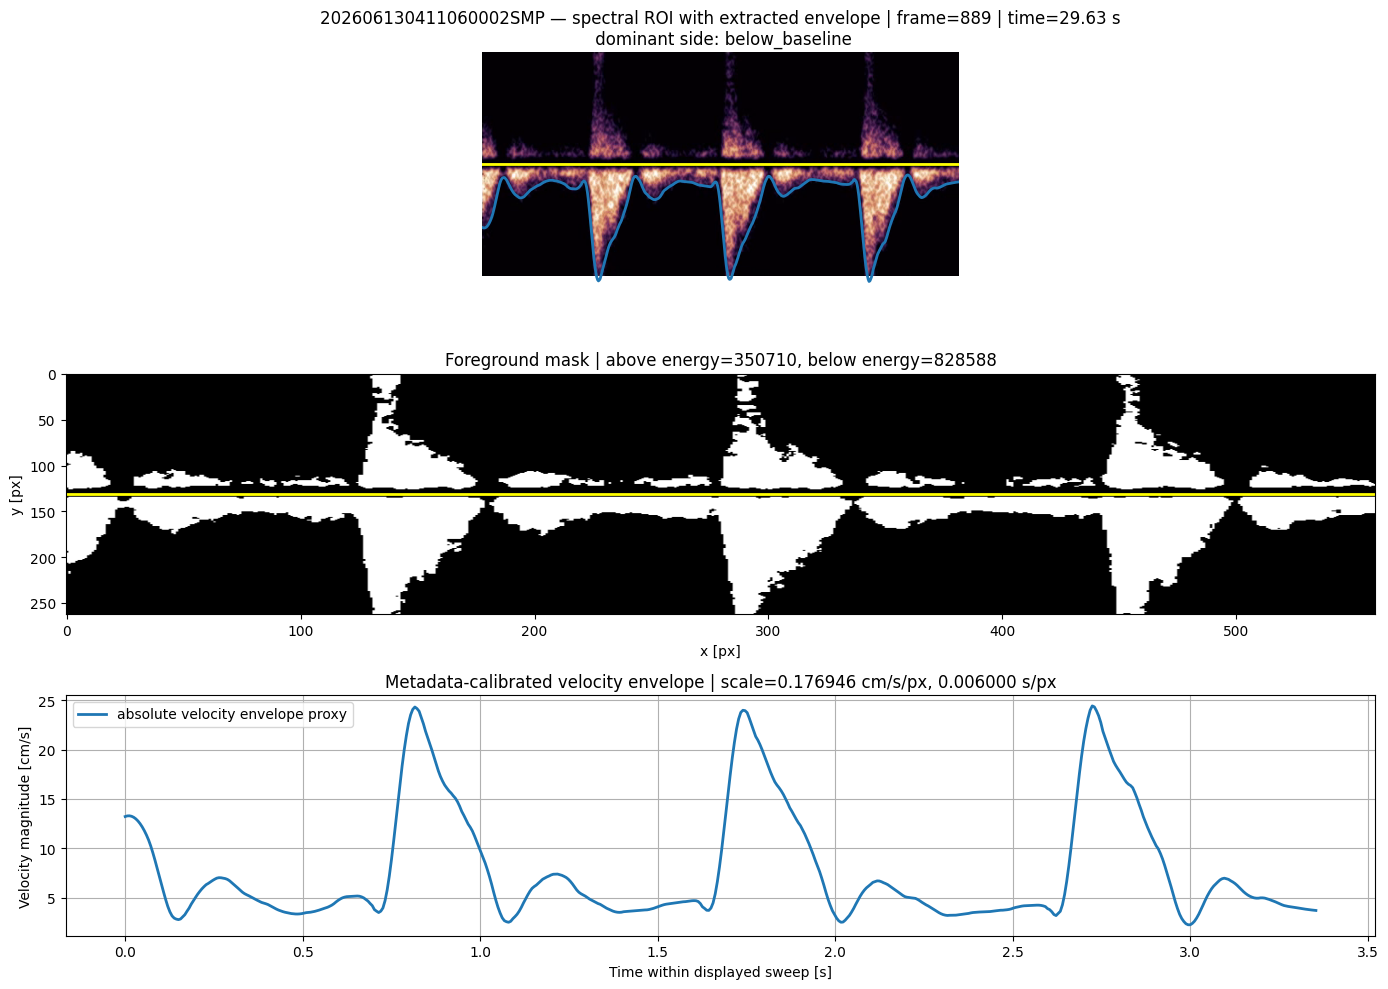

202606130411060002SMP
dominant_side: below_baseline
interpolation_success: True
valid_column_fraction: 0.9910714285714286
velocity_abs_cm_s range: 2.2725682311630253 24.414987016561188
--------------------------------------------------------------------------------


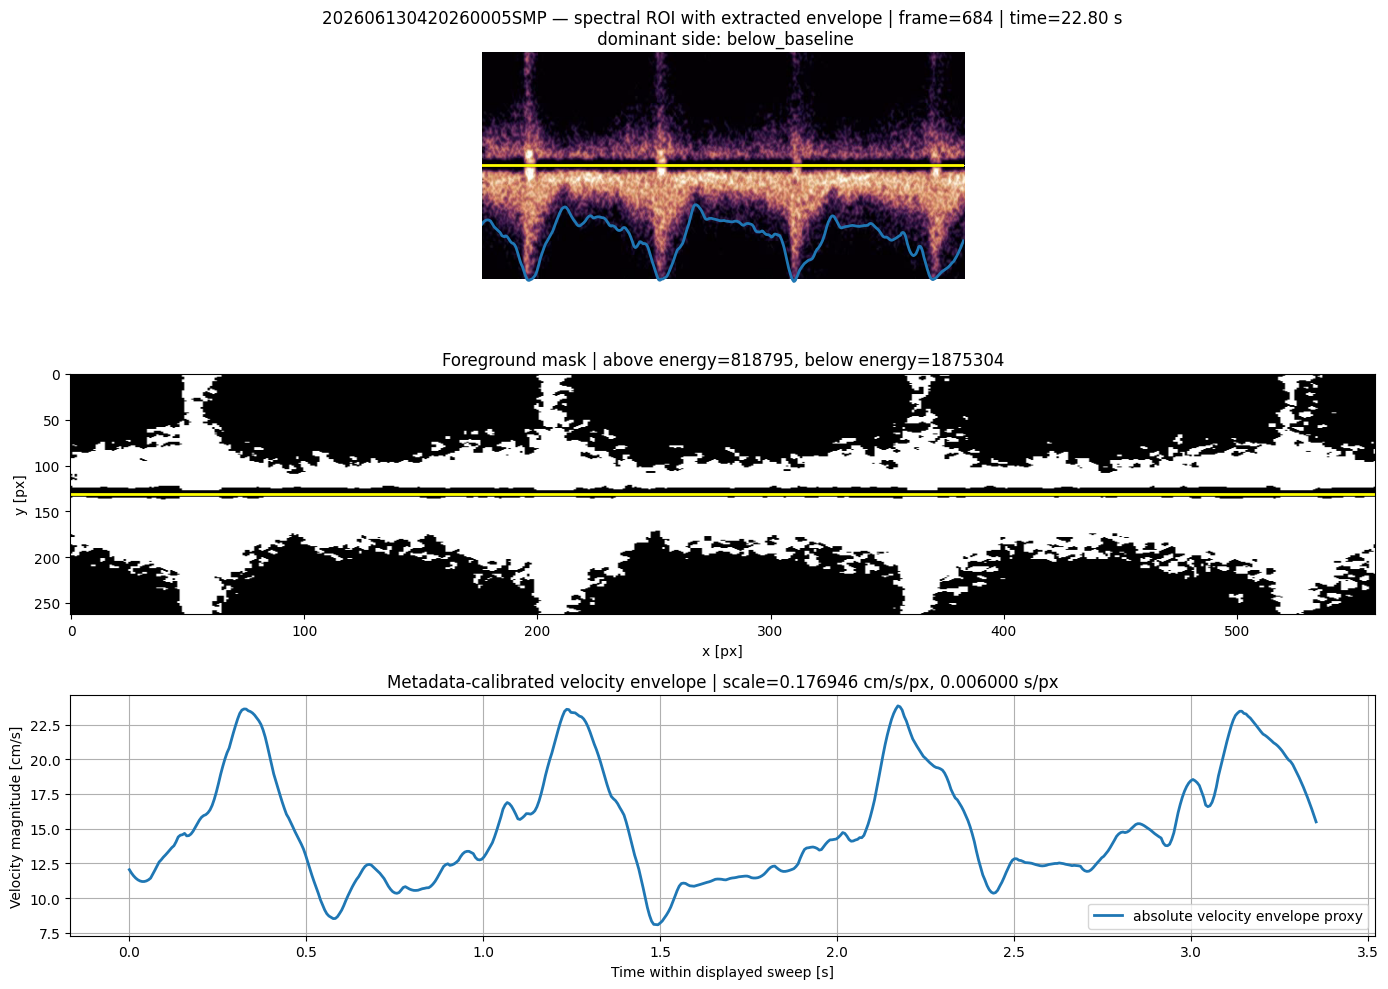

202606130420260005SMP
dominant_side: below_baseline
interpolation_success: True
valid_column_fraction: 1.0
velocity_abs_cm_s range: 8.087965887155638 23.841749838545297
--------------------------------------------------------------------------------


In [23]:
envelope_results = {}

for _, config_row in pw_config_df.iterrows():
    frame_rgb, frame_info = read_video_frame_at_time(
        video_path=config_row["avi_path"],
        time_s=0.5 * float(config_row["duration_s"]),
        convert_to_rgb=True,
    )

    signal_df, extraction_debug = extract_metadata_assisted_velocity_envelope_from_frame(
        frame_rgb=frame_rgb,
        config_row=config_row,
        right_margin_px=20,
        baseline_exclusion_px=3,
        value_threshold=35,
        saturation_threshold=25,
        gray_threshold=30,
        min_distance_from_baseline_px=3,
    )

    envelope_results[config_row["recording_id"]] = {
        "config_row": config_row,
        "frame_rgb": frame_rgb,
        "frame_info": frame_info,
        "signal_df": signal_df,
        "extraction_debug": extraction_debug,
    }

    plot_metadata_assisted_envelope_extraction(
        signal_df=signal_df,
        extraction_debug=extraction_debug,
        config_row=config_row,
        frame_info=frame_info,
        figsize=(14, 10),
    )

    print(config_row["recording_id"])
    print("dominant_side:", extraction_debug["dominant_side"])
    print("interpolation_success:", extraction_debug["interpolation_success"])
    print("valid_column_fraction:", signal_df["valid_column"].mean())
    print("velocity_abs_cm_s range:", signal_df["velocity_abs_cm_s"].min(), signal_df["velocity_abs_cm_s"].max())
    print("-" * 80)

## Beat detection from the calibrated velocity envelope

This section detects candidate systolic peaks from the metadata-calibrated Doppler velocity envelope.

The detected peaks are used as beat markers for downstream beat-level proxy feature extraction.

The detection is performed on the velocity magnitude from the dominant Doppler side. This is appropriate for this proof-of-concept because the selected recordings show the main useful spectral envelope below the zero-velocity baseline.

Detected beats are candidate signal-processing events. They are not yet clinically validated cardiac cycle annotations.

In [24]:
def detect_velocity_envelope_beats(
    signal_df,
    velocity_column="velocity_abs_cm_s",
    time_column="time_s",
    min_hr_bpm=45,
    max_hr_bpm=140,
    prominence_fraction=0.20,
    min_prominence_cm_s=2.0,
    min_height_percentile=60,
    smoothing_window_points=11,
    smoothing_polyorder=2,
):
    """
    Detect candidate systolic peaks in a calibrated Doppler velocity envelope.

    The function smooths the velocity magnitude, estimates an adaptive peak
    prominence threshold, and detects local maxima that are plausible
    systolic velocity peaks.

    Parameters
    ----------
    signal_df : pandas.DataFrame
        Velocity envelope table containing time and velocity columns.

    velocity_column : str
        Name of the velocity magnitude column.

    time_column : str
        Name of the time column.

    min_hr_bpm : float
        Lower plausible heart-rate bound used to avoid excessive peak spacing.

    max_hr_bpm : float
        Upper plausible heart-rate bound used to enforce minimum peak spacing.

    prominence_fraction : float
        Fraction of robust signal amplitude used as adaptive prominence.

    min_prominence_cm_s : float
        Minimum absolute prominence threshold in cm/s.

    min_height_percentile : float
        Percentile used as the minimum peak height threshold.

    smoothing_window_points : int
        Window length for Savitzky-Golay smoothing. The value is adjusted to
        an odd number when needed.

    smoothing_polyorder : int
        Polynomial order for Savitzky-Golay smoothing.

    Returns
    -------
    peak_df : pandas.DataFrame
        Table with one row per detected peak.

    detection_debug : dict
        Detection thresholds and intermediate arrays.
    """
    time_s = signal_df[time_column].to_numpy(dtype=float)
    velocity_cm_s = signal_df[velocity_column].to_numpy(dtype=float)

    valid_mask = np.isfinite(time_s) & np.isfinite(velocity_cm_s)

    if np.sum(valid_mask) < 5:
        peak_df = pd.DataFrame()
        detection_debug = {
            "success": False,
            "reason": "Not enough valid samples for beat detection.",
        }
        return peak_df, detection_debug

    time_s = time_s[valid_mask]
    velocity_cm_s = velocity_cm_s[valid_mask]

    dt_s = float(np.median(np.diff(time_s)))

    if not np.isfinite(dt_s) or dt_s <= 0:
        peak_df = pd.DataFrame()
        detection_debug = {
            "success": False,
            "reason": "Invalid time step.",
        }
        return peak_df, detection_debug

    velocity_smooth_cm_s = velocity_cm_s.copy()

    if smoothing_window_points is not None and smoothing_window_points >= 5:
        if smoothing_window_points % 2 == 0:
            smoothing_window_points += 1

        if smoothing_window_points < len(velocity_smooth_cm_s):
            velocity_smooth_cm_s = savgol_filter(
                velocity_smooth_cm_s,
                window_length=smoothing_window_points,
                polyorder=smoothing_polyorder,
                mode="interp",
            )

    robust_low = float(np.nanpercentile(velocity_smooth_cm_s, 5))
    robust_high = float(np.nanpercentile(velocity_smooth_cm_s, 95))
    robust_range = robust_high - robust_low

    prominence_cm_s = max(float(min_prominence_cm_s), float(prominence_fraction) * robust_range)

    height_cm_s = float(np.nanpercentile(velocity_smooth_cm_s, min_height_percentile))

    min_rr_s = 60.0 / float(max_hr_bpm)
    max_rr_s = 60.0 / float(min_hr_bpm)

    min_peak_distance_points = max(1, int(round(min_rr_s / dt_s)))

    peak_indices, peak_properties = find_peaks(
        velocity_smooth_cm_s,
        distance=min_peak_distance_points,
        prominence=prominence_cm_s,
        height=height_cm_s,
    )

    peak_rows = []

    for local_order, peak_index in enumerate(peak_indices):
        peak_time_s = float(time_s[peak_index])
        peak_velocity_cm_s = float(velocity_smooth_cm_s[peak_index])

        if local_order == 0:
            rr_prev_s = np.nan
            hr_from_prev_bpm = np.nan
        else:
            rr_prev_s = peak_time_s - float(time_s[peak_indices[local_order - 1]])
            hr_from_prev_bpm = 60.0 / rr_prev_s if rr_prev_s > 0 else np.nan

        if local_order == len(peak_indices) - 1:
            rr_next_s = np.nan
            hr_to_next_bpm = np.nan
        else:
            rr_next_s = float(time_s[peak_indices[local_order + 1]]) - peak_time_s
            hr_to_next_bpm = 60.0 / rr_next_s if rr_next_s > 0 else np.nan

        rr_is_plausible = True

        if np.isfinite(rr_prev_s):
            rr_is_plausible = rr_is_plausible and (min_rr_s <= rr_prev_s <= max_rr_s)
        if np.isfinite(rr_next_s):
            rr_is_plausible = rr_is_plausible and (min_rr_s <= rr_next_s <= max_rr_s)

        peak_rows.append(
            {
                "peak_order": local_order,
                "peak_index": int(peak_index),
                "peak_time_s": peak_time_s,
                "psv_proxy_cm_s": peak_velocity_cm_s,
                "rr_prev_s": rr_prev_s,
                "hr_from_prev_bpm": hr_from_prev_bpm,
                "rr_next_s": rr_next_s,
                "hr_to_next_bpm": hr_to_next_bpm,
                "peak_prominence_cm_s": float(peak_properties["prominences"][local_order]),
                "peak_height_cm_s": float(peak_properties["peak_heights"][local_order]),
                "rr_is_plausible": bool(rr_is_plausible),
            }
        )

    peak_df = pd.DataFrame(peak_rows)

    detection_debug = {
        "success": True,
        "dt_s": dt_s,
        "robust_low_cm_s": robust_low,
        "robust_high_cm_s": robust_high,
        "robust_range_cm_s": robust_range,
        "prominence_cm_s": prominence_cm_s,
        "height_cm_s": height_cm_s,
        "min_rr_s": min_rr_s,
        "max_rr_s": max_rr_s,
        "min_peak_distance_points": min_peak_distance_points,
        "time_s": time_s,
        "velocity_cm_s": velocity_cm_s,
        "velocity_smooth_cm_s": velocity_smooth_cm_s,
        "peak_indices": peak_indices,
        "peak_properties": peak_properties,
    }

    return peak_df, detection_debug

In [25]:
def plot_velocity_envelope_with_detected_beats(
    signal_df,
    peak_df,
    detection_debug,
    config_row,
    frame_info=None,
    velocity_column="velocity_abs_cm_s",
    time_column="time_s",
    figsize=(14, 5),
):
    """
    Plot a calibrated Doppler velocity envelope with detected beat markers.

    The function displays the smoothed velocity envelope and overlays detected
    candidate systolic peaks. The plot is used to inspect whether peak
    detection is reasonable before beat-level feature extraction is performed.

    Parameters
    ----------
    signal_df : pandas.DataFrame
        Velocity envelope table.

    peak_df : pandas.DataFrame
        Detected peak table returned by detect_velocity_envelope_beats().

    detection_debug : dict
        Detection debug dictionary.

    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    frame_info : dict or None
        Frame metadata from read_video_frame_at_time().

    velocity_column : str
        Name of the velocity magnitude column.

    time_column : str
        Name of the time column.

    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    None
        The function displays a plot.
    """
    recording_id = config_row["recording_id"]

    time_s = signal_df[time_column].to_numpy(dtype=float)
    velocity_cm_s = signal_df[velocity_column].to_numpy(dtype=float)

    if detection_debug.get("success", False):
        debug_time_s = detection_debug["time_s"]
        velocity_smooth_cm_s = detection_debug["velocity_smooth_cm_s"]
        prominence_cm_s = detection_debug["prominence_cm_s"]
        height_cm_s = detection_debug["height_cm_s"]
    else:
        debug_time_s = time_s
        velocity_smooth_cm_s = velocity_cm_s
        prominence_cm_s = np.nan
        height_cm_s = np.nan

    title_suffix = ""

    if frame_info is not None:
        title_suffix = (f" | frame={frame_info['actual_frame_index']} | time={frame_info['actual_time_s']:.2f} s")

    plt.figure(figsize=figsize)
    plt.plot(time_s, velocity_cm_s, linewidth=1, alpha=0.45, label="raw velocity envelope proxy")

    plt.plot(
        debug_time_s,
        velocity_smooth_cm_s,
        linewidth=2,
        label="smoothed velocity envelope proxy",
    )

    if len(peak_df) > 0:
        plt.scatter(
            peak_df["peak_time_s"],
            peak_df["psv_proxy_cm_s"],
            s=70,
            marker="o",
            label="detected PSV proxy peaks",
        )

        for _, peak_row in peak_df.iterrows():
            plt.text(
                peak_row["peak_time_s"],
                peak_row["psv_proxy_cm_s"] + 0.6,
                str(int(peak_row["peak_order"])),
                ha="center",
                fontsize=9,
            )

    if np.isfinite(height_cm_s):
        plt.axhline(
            height_cm_s,
            linestyle="--",
            linewidth=1,
            label=f"height threshold={height_cm_s:.1f} cm/s",
        )

    plt.xlabel("Time within displayed sweep [s]")
    plt.ylabel("Velocity magnitude [cm/s]")
    plt.title(f"{recording_id} — detected candidate beats{title_suffix}\nprominence threshold={prominence_cm_s:.2f} cm/s")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

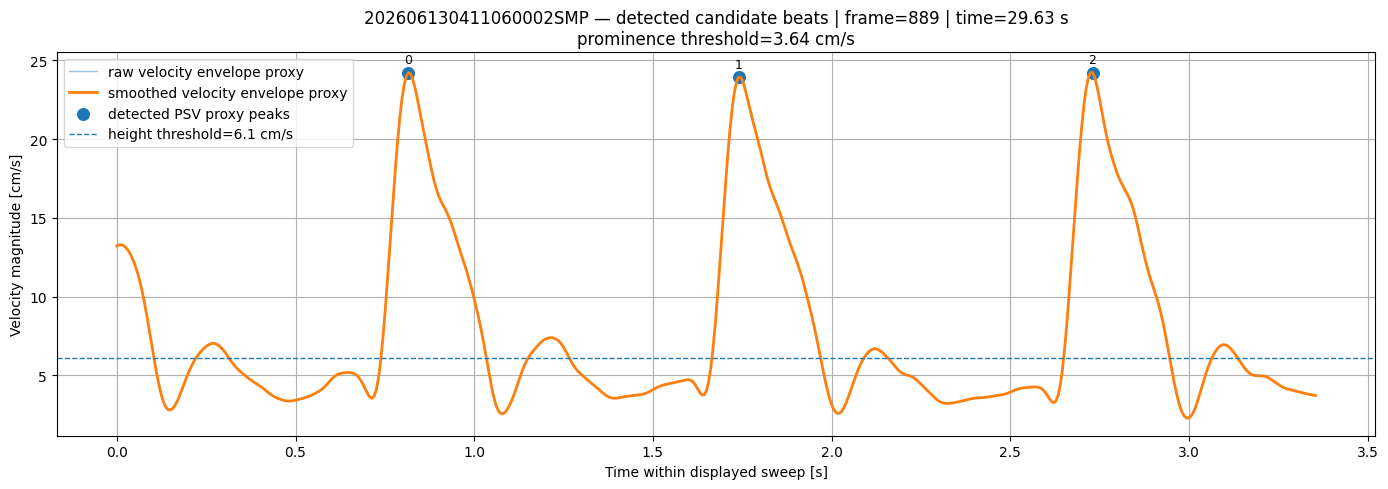

202606130411060002SMP
n_detected_peaks: 3
dt_s: 0.006000000052154064
height_cm_s: 6.123225450233772
prominence_cm_s: 3.638305395864582
min_rr_s: 0.42857142857142855
max_rr_s: 1.3333333333333333


,peak_order,peak_index,peak_time_s,psv_proxy_cm_s,rr_prev_s,hr_from_prev_bpm,rr_next_s,hr_to_next_bpm,peak_prominence_cm_s,peak_height_cm_s,rr_is_plausible
0,0,136,0.816,24.217445,NaN,NaN,0.924,64.935064,21.418074,24.217445,True
1,1,290,1.740,23.941292,0.924,64.935064,0.990,60.606060,21.345540,23.941292,True
2,2,455,2.730,24.227271,0.990,60.606060,NaN,NaN,21.667394,24.227271,True


--------------------------------------------------------------------------------


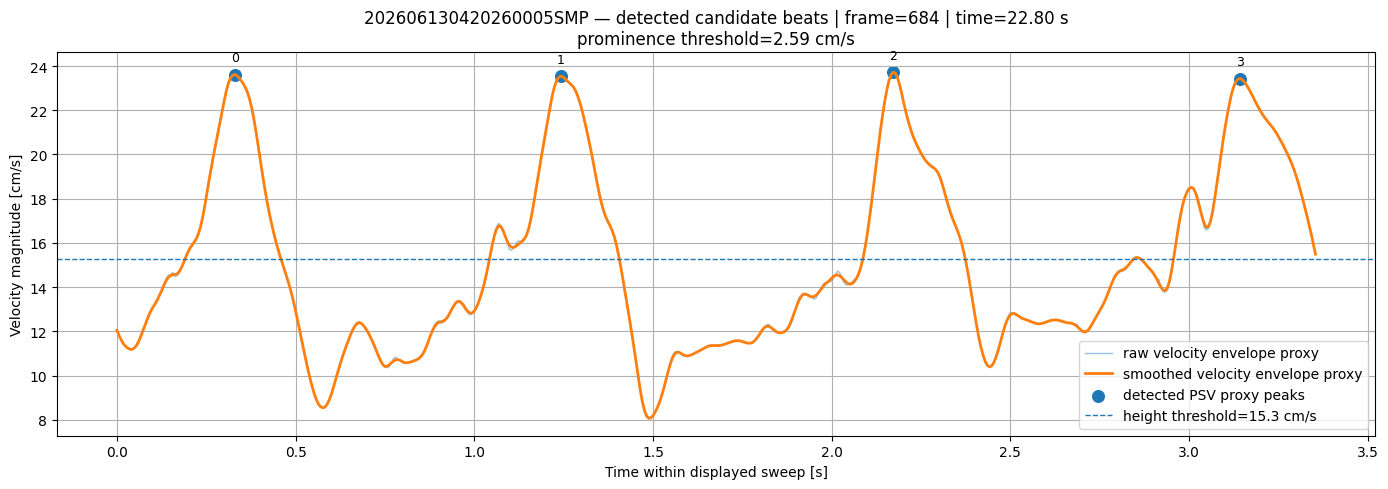

202606130420260005SMP
n_detected_peaks: 4
dt_s: 0.006000000052154064
height_cm_s: 15.274670586988908
prominence_cm_s: 2.588655241885907
min_rr_s: 0.42857142857142855
max_rr_s: 1.3333333333333333


,peak_order,peak_index,peak_time_s,psv_proxy_cm_s,rr_prev_s,hr_from_prev_bpm,rr_next_s,hr_to_next_bpm,peak_prominence_cm_s,peak_height_cm_s,rr_is_plausible
0,0,55,0.330,23.618020,NaN,NaN,0.912,65.789473,12.430595,23.618020,True
1,1,207,1.242,23.544089,0.912,65.789473,0.930,64.516128,15.002552,23.544089,True
2,2,362,2.172,23.719869,0.930,64.516128,0.972,61.728395,13.320812,23.719869,True
3,3,524,3.144,23.427322,0.972,61.728395,NaN,NaN,7.934027,23.427322,True


--------------------------------------------------------------------------------


In [26]:
beat_detection_results = {}

for recording_id, result in envelope_results.items():
    signal_df = result["signal_df"]
    config_row = result["config_row"]
    frame_info = result["frame_info"]

    peak_df, detection_debug = detect_velocity_envelope_beats(
        signal_df=signal_df,
        velocity_column="velocity_abs_cm_s",
        time_column="time_s",
        min_hr_bpm=45,
        max_hr_bpm=140,
        prominence_fraction=0.20,
        min_prominence_cm_s=2.0,
        min_height_percentile=60,
        smoothing_window_points=11,
        smoothing_polyorder=2,
    )

    beat_detection_results[recording_id] = {"peak_df": peak_df, "detection_debug": detection_debug,}
    plot_velocity_envelope_with_detected_beats(
        signal_df=signal_df,
        peak_df=peak_df,
        detection_debug=detection_debug,
        config_row=config_row,
        frame_info=frame_info,
        figsize=(14, 5),
    )

    print(recording_id)
    print("n_detected_peaks:", len(peak_df))

    if detection_debug.get("success", False):
        print("dt_s:", detection_debug["dt_s"])
        print("height_cm_s:", detection_debug["height_cm_s"])
        print("prominence_cm_s:", detection_debug["prominence_cm_s"])
        print("min_rr_s:", detection_debug["min_rr_s"])
        print("max_rr_s:", detection_debug["max_rr_s"])

    display(peak_df)

    print("-" * 80)

## Beat-level hemodynamic proxy features

This section computes beat-level Doppler proxy features from consecutive detected systolic peaks.

Each complete candidate beat is defined as the interval from one detected systolic peak to the next detected systolic peak.

The extracted values are treated as signal-processing proxy features:

```text
PSV proxy
EDV proxy
RI proxy
S/D ratio proxy
PI proxy
VTI proxy
acceleration time proxy
systolic upslope proxy

In [27]:
def extract_complete_beat_hemodynamic_features(
    signal_df,
    peak_df,
    recording_id,
    velocity_column="velocity_abs_cm_s",
    time_column="time_s",
    late_diastolic_fraction=0.25,
    pre_peak_search_window_s=0.45,
    peak_exclusion_s=0.03,
    min_pre_peak_window_s=0.12,
    min_beat_duration_s=0.40,
    max_beat_duration_s=1.40,
    min_psv_cm_s=5.0,
    min_velocity_range_cm_s=3.0,
):
    """
    Extract beat-level Doppler hemodynamic proxy features.

    The function defines each complete candidate beat as the interval from
    one detected systolic peak to the next detected systolic peak.

    PSV proxy is taken from the current detected peak. EDV proxy is estimated
    from the late-diastolic part of the peak-to-peak interval. VTI proxy is
    calculated as the numerical integral of the velocity envelope over the
    peak-to-peak interval.

    Acceleration time proxy is estimated separately by searching for a local
    pre-systolic foot in a window before the current detected PSV peak.

    The extracted values are signal-processing proxy features and should not
    be interpreted as clinically validated Doppler measurements.

    Parameters
    ----------
    signal_df : pandas.DataFrame
        Velocity envelope table.

    peak_df : pandas.DataFrame
        Detected peak table returned by detect_velocity_envelope_beats().

    recording_id : str
        Recording identifier assigned to output rows.

    velocity_column : str
        Name of the velocity magnitude column.

    time_column : str
        Name of the time column.

    late_diastolic_fraction : float
        Fraction of the final beat interval used to estimate EDV proxy.

    pre_peak_search_window_s : float
        Time window before the PSV peak searched for the acceleration foot.

    peak_exclusion_s : float
        Small time interval before the PSV peak excluded from foot search.

    min_pre_peak_window_s : float
        Minimum required pre-peak window duration for acceleration time
        estimation.

    min_beat_duration_s : float
        Minimum plausible complete beat duration.

    max_beat_duration_s : float
        Maximum plausible complete beat duration.

    min_psv_cm_s : float
        Minimum plausible PSV proxy used for quality flagging.

    min_velocity_range_cm_s : float
        Minimum PSV-EDV difference used for quality flagging.

    Returns
    -------
    beat_feature_df : pandas.DataFrame
        Beat-level feature table with one row per complete candidate beat.
    """
    if peak_df is None or len(peak_df) < 2:
        return pd.DataFrame()

    time_s = signal_df[time_column].to_numpy(dtype=float)
    velocity_cm_s = signal_df[velocity_column].to_numpy(dtype=float)

    valid_signal_mask = np.isfinite(time_s) & np.isfinite(velocity_cm_s)

    time_s = time_s[valid_signal_mask]
    velocity_cm_s = velocity_cm_s[valid_signal_mask]

    if len(time_s) < 5:
        return pd.DataFrame()

    signal_start_time_s = float(np.nanmin(time_s))
    signal_end_time_s = float(np.nanmax(time_s))

    beat_rows = []

    peak_df_sorted = peak_df.sort_values("peak_time_s").reset_index(drop=True)

    for beat_order in range(len(peak_df_sorted) - 1):
        current_peak = peak_df_sorted.iloc[beat_order]
        next_peak = peak_df_sorted.iloc[beat_order + 1]

        start_time_s = float(current_peak["peak_time_s"])
        end_time_s = float(next_peak["peak_time_s"])
        beat_duration_s = end_time_s - start_time_s

        beat_mask = (time_s >= start_time_s) & (time_s < end_time_s)

        if np.sum(beat_mask) < 5:
            continue

        beat_time_s = time_s[beat_mask]
        beat_velocity_cm_s = velocity_cm_s[beat_mask]

        psv_proxy_cm_s = float(current_peak["psv_proxy_cm_s"])

        late_start_time_s = start_time_s + (1.0 - late_diastolic_fraction) * beat_duration_s
        late_mask = beat_time_s >= late_start_time_s

        if np.sum(late_mask) >= 3:
            late_velocity_cm_s = beat_velocity_cm_s[late_mask]
            edv_proxy_cm_s = float(np.nanmedian(late_velocity_cm_s))
            edv_min_proxy_cm_s = float(np.nanmin(late_velocity_cm_s))
        else:
            edv_proxy_cm_s = float(beat_velocity_cm_s[-1])
            edv_min_proxy_cm_s = float(beat_velocity_cm_s[-1])

        mean_velocity_proxy_cm_s = float(np.nanmean(beat_velocity_cm_s))
        velocity_range_cm_s = psv_proxy_cm_s - edv_proxy_cm_s

        if psv_proxy_cm_s > 0:
            ri_proxy = velocity_range_cm_s / psv_proxy_cm_s
        else:
            ri_proxy = np.nan

        if edv_proxy_cm_s > 0:
            sd_ratio_proxy = psv_proxy_cm_s / edv_proxy_cm_s
        else:
            sd_ratio_proxy = np.nan

        if mean_velocity_proxy_cm_s > 0:
            pi_proxy = velocity_range_cm_s / mean_velocity_proxy_cm_s
        else:
            pi_proxy = np.nan

        if hasattr(np, "trapezoid"):
            vti_proxy_cm = float(np.trapezoid(beat_velocity_cm_s, beat_time_s))
        else:
            vti_proxy_cm = float(np.trapz(beat_velocity_cm_s, beat_time_s))

        requested_foot_search_start_s = start_time_s - float(pre_peak_search_window_s)
        foot_search_start_s = max(signal_start_time_s, requested_foot_search_start_s)
        foot_search_end_s = max(signal_start_time_s, start_time_s - float(peak_exclusion_s))

        pre_peak_mask = ((time_s >= foot_search_start_s) & (time_s <= foot_search_end_s))

        actual_pre_peak_window_s = foot_search_end_s - foot_search_start_s

        if (
            actual_pre_peak_window_s >= min_pre_peak_window_s and np.sum(pre_peak_mask) >= 3):
            pre_peak_time_s = time_s[pre_peak_mask]
            pre_peak_velocity_cm_s = velocity_cm_s[pre_peak_mask]

            foot_local_index = int(np.nanargmin(pre_peak_velocity_cm_s))
            foot_time_s = float(pre_peak_time_s[foot_local_index])
            foot_velocity_cm_s = float(pre_peak_velocity_cm_s[foot_local_index])

            acceleration_time_proxy_s = start_time_s - foot_time_s

            if acceleration_time_proxy_s > 0:
                systolic_upslope_proxy_cm_s2 = (psv_proxy_cm_s - foot_velocity_cm_s) / acceleration_time_proxy_s
                acceleration_quality_flag = "ok"
            else:
                acceleration_time_proxy_s = np.nan
                systolic_upslope_proxy_cm_s2 = np.nan
                acceleration_quality_flag = "invalid_acceleration_time"
        else:
            foot_time_s = np.nan
            foot_velocity_cm_s = np.nan
            acceleration_time_proxy_s = np.nan
            systolic_upslope_proxy_cm_s2 = np.nan
            acceleration_quality_flag = "insufficient_pre_peak_window"

        if requested_foot_search_start_s < signal_start_time_s:
            if acceleration_quality_flag == "ok":
                acceleration_quality_flag = "edge_limited_pre_peak_window"
            else:
                acceleration_quality_flag = (acceleration_quality_flag + ";edge_limited_pre_peak_window")

        quality_flags = []

        if not (min_beat_duration_s <= beat_duration_s <= max_beat_duration_s):
            quality_flags.append("implausible_rr")

        if psv_proxy_cm_s < min_psv_cm_s:
            quality_flags.append("low_psv")

        if velocity_range_cm_s < min_velocity_range_cm_s:
            quality_flags.append("low_velocity_range")

        if edv_proxy_cm_s <= 0:
            quality_flags.append("non_positive_edv_proxy")

        if not np.isfinite(ri_proxy) or ri_proxy < 0 or ri_proxy > 1.2:
            quality_flags.append("ri_proxy_out_of_range")

        if not np.isfinite(vti_proxy_cm) or vti_proxy_cm <= 0:
            quality_flags.append("invalid_vti_proxy")

        if len(quality_flags) == 0:
            beat_quality_flag = "ok"
        else:
            beat_quality_flag = ";".join(quality_flags)

        beat_rows.append(
            {
                "recording_id": recording_id,
                "beat_order": beat_order,
                "start_peak_order": int(current_peak["peak_order"]),
                "next_peak_order": int(next_peak["peak_order"]),
                "start_time_s": start_time_s,
                "end_time_s": end_time_s,
                "rr_s": beat_duration_s,
                "hr_bpm": 60.0 / beat_duration_s if beat_duration_s > 0 else np.nan,
                "psv_proxy_cm_s": psv_proxy_cm_s,
                "edv_proxy_cm_s": edv_proxy_cm_s,
                "edv_min_proxy_cm_s": edv_min_proxy_cm_s,
                "mean_velocity_proxy_cm_s": mean_velocity_proxy_cm_s,
                "ri_proxy": ri_proxy,
                "sd_ratio_proxy": sd_ratio_proxy,
                "pi_proxy": pi_proxy,
                "vti_proxy_cm": vti_proxy_cm,
                "foot_time_s": foot_time_s,
                "foot_velocity_cm_s": foot_velocity_cm_s,
                "foot_search_start_s": foot_search_start_s,
                "foot_search_end_s": foot_search_end_s,
                "actual_pre_peak_window_s": actual_pre_peak_window_s,
                "acceleration_time_proxy_s": acceleration_time_proxy_s,
                "systolic_upslope_proxy_cm_s2": systolic_upslope_proxy_cm_s2,
                "velocity_range_cm_s": velocity_range_cm_s,
                "n_samples": int(len(beat_time_s)),
                "beat_quality_flag": beat_quality_flag,
                "acceleration_quality_flag": acceleration_quality_flag,
            }
        )

    beat_feature_df = pd.DataFrame(beat_rows)

    return beat_feature_df

In [28]:
beat_feature_tables = []

for recording_id, result in envelope_results.items():
    signal_df = result["signal_df"]
    peak_df = beat_detection_results[recording_id]["peak_df"]

    beat_feature_df = extract_complete_beat_hemodynamic_features(
        signal_df=signal_df,
        peak_df=peak_df,
        recording_id=recording_id,
        velocity_column="velocity_abs_cm_s",
        time_column="time_s",
        late_diastolic_fraction=0.25,
        pre_peak_search_window_s=0.45,
        peak_exclusion_s=0.03,
        min_pre_peak_window_s=0.12,
        min_beat_duration_s=0.40,
        max_beat_duration_s=1.40,
        min_psv_cm_s=5.0,
        min_velocity_range_cm_s=3.0,
    )

    beat_feature_tables.append(beat_feature_df)

beat_feature_df = pd.concat(
    beat_feature_tables,
    ignore_index=True,
)

display(
    beat_feature_df[
        [
            "recording_id",
            "beat_order",
            "rr_s",
            "hr_bpm",
            "psv_proxy_cm_s",
            "edv_proxy_cm_s",
            "ri_proxy",
            "sd_ratio_proxy",
            "pi_proxy",
            "vti_proxy_cm",
            "foot_velocity_cm_s",
            "acceleration_time_proxy_s",
            "systolic_upslope_proxy_cm_s2",
            "beat_quality_flag",
            "acceleration_quality_flag",
        ]
    ]
)

,recording_id,beat_order,rr_s,hr_bpm,psv_proxy_cm_s,edv_proxy_cm_s,ri_proxy,sd_ratio_proxy,pi_proxy,vti_proxy_cm,foot_velocity_cm_s,acceleration_time_proxy_s,systolic_upslope_proxy_cm_s2,beat_quality_flag,acceleration_quality_flag
0,202606130411060002SMP,0,0.924,64.935064,24.217445,4.620199,0.809220,5.241645,2.400958,7.397768,3.360870,0.330,63.201740,ok,ok
1,202606130411060002SMP,1,0.990,60.606060,23.941292,4.226106,0.823480,5.665095,2.494301,7.679894,3.527346,0.348,58.660761,ok,ok
2,202606130420260005SMP,0,0.912,65.789473,23.618020,16.496881,0.301513,1.431666,0.499432,12.862119,11.202018,0.288,43.111119,ok,edge_limited_pre_peak_window
3,202606130420260005SMP,1,0.930,64.516128,23.544089,14.496162,0.384297,1.624160,0.640261,13.000883,10.560290,0.432,30.055090,ok,ok
4,202606130420260005SMP,2,0.972,61.728395,23.719869,17.698915,0.253836,1.340188,0.386807,14.988064,11.453695,0.408,30.064152,ok,ok


## Recording-level summary and annotated example beat

This section aggregates beat-level proxy features into a compact recording-level summary.

The summary is calculated from complete candidate beats extracted from one representative displayed Doppler sweep per recording.

The annotated example beat visualizes the main feature definitions on the calibrated velocity envelope:

```text
PSV proxy
EDV proxy
RI proxy
VTI proxy
acceleration time proxy

In [29]:
def summarize_recording_level_hemodynamic_features(beat_feature_df, ok_quality_value="ok"):
    """
    Summarize beat-level Doppler proxy features at the recording level.

    The function aggregates complete candidate beats into one row per
    recording. It reports the number of beats, basic rhythm statistics,
    central tendency for Doppler proxy features, and quality-flag counts.

    The summary represents one selected displayed Doppler sweep per recording.
    It should not be interpreted as a validated full-recording clinical
    summary.

    Parameters
    ----------
    beat_feature_df : pandas.DataFrame
        Beat-level hemodynamic proxy feature table.

    ok_quality_value : str
        Value used in beat_quality_flag to indicate a beat without basic
        technical quality warnings.

    Returns
    -------
    recording_summary_df : pandas.DataFrame
        Recording-level summary table.
    """

    if beat_feature_df is None or len(beat_feature_df) == 0:
        return pd.DataFrame()

    summary_rows = []

    numeric_summary_columns = [
        "rr_s",
        "hr_bpm",
        "psv_proxy_cm_s",
        "edv_proxy_cm_s",
        "ri_proxy",
        "sd_ratio_proxy",
        "pi_proxy",
        "vti_proxy_cm",
        "acceleration_time_proxy_s",
        "systolic_upslope_proxy_cm_s2",
    ]

    for recording_id, group_df in beat_feature_df.groupby("recording_id"):
        group_df = group_df.copy()

        n_complete_beats = int(len(group_df))
        n_basic_quality_ok = int(np.sum(group_df["beat_quality_flag"] == ok_quality_value))

        if "acceleration_quality_flag" in group_df.columns:
            n_acceleration_ok = int(np.sum(group_df["acceleration_quality_flag"] == ok_quality_value))
            acceleration_flags = (
                group_df["acceleration_quality_flag"]
                .fillna("missing")
                .value_counts()
                .to_dict()
            )
        else:
            n_acceleration_ok = 0
            acceleration_flags = {}

        beat_flags = (
            group_df["beat_quality_flag"]
            .fillna("missing")
            .value_counts()
            .to_dict()
        )

        row = {
            "recording_id": recording_id,
            "n_complete_beats": n_complete_beats,
            "n_basic_quality_ok": n_basic_quality_ok,
            "basic_quality_ok_fraction": (
                n_basic_quality_ok / n_complete_beats
                if n_complete_beats > 0
                else np.nan
            ),
            "n_acceleration_ok": n_acceleration_ok,
            "acceleration_ok_fraction": (
                n_acceleration_ok / n_complete_beats
                if n_complete_beats > 0
                else np.nan
            ),
            "beat_quality_flags": beat_flags,
            "acceleration_quality_flags": acceleration_flags,
        }

        for column in numeric_summary_columns:
            values = group_df[column].to_numpy(dtype=float)

            row[f"{column}_mean"] = float(np.nanmean(values))
            row[f"{column}_median"] = float(np.nanmedian(values))
            row[f"{column}_std"] = float(np.nanstd(values, ddof=1)) if np.sum(np.isfinite(values)) > 1 else np.nan

        summary_rows.append(row)

    recording_summary_df = pd.DataFrame(summary_rows)

    return recording_summary_df.sort_values("recording_id").reset_index(drop=True)

In [30]:
recording_summary_df = summarize_recording_level_hemodynamic_features(beat_feature_df=beat_feature_df,)

display(
    recording_summary_df[
        [
            "recording_id",
            "n_complete_beats",
            "basic_quality_ok_fraction",
            "acceleration_ok_fraction",
            "rr_s_mean",
            "hr_bpm_mean",
            "psv_proxy_cm_s_mean",
            "edv_proxy_cm_s_mean",
            "ri_proxy_mean",
            "sd_ratio_proxy_mean",
            "pi_proxy_mean",
            "vti_proxy_cm_mean",
            "acceleration_time_proxy_s_mean",
            "systolic_upslope_proxy_cm_s2_mean",
            "beat_quality_flags",
            "acceleration_quality_flags",
        ]
    ]
)

,recording_id,n_complete_beats,basic_quality_ok_fraction,acceleration_ok_fraction,rr_s_mean,hr_bpm_mean,psv_proxy_cm_s_mean,edv_proxy_cm_s_mean,ri_proxy_mean,sd_ratio_proxy_mean,pi_proxy_mean,vti_proxy_cm_mean,acceleration_time_proxy_s_mean,systolic_upslope_proxy_cm_s2_mean,beat_quality_flags,acceleration_quality_flags
0,202606130411060002SMP,2,1.0,1.000000,0.957,62.770562,24.079368,4.423152,0.816350,5.453370,2.447630,7.538831,0.339,60.931251,{'ok': 2},{'ok': 2}
1,202606130420260005SMP,3,1.0,0.666667,0.938,64.011332,23.627326,16.230652,0.313215,1.465338,0.508833,13.617022,0.376,34.410120,{'ok': 3},"{'ok': 2, 'edge_limited_pre_peak_window': 1}"


## Final demo tables

This section prepares compact display tables for the notebook discussion.

The tables use rounded values and proxy feature names. The goal is readability, not additional analysis.

In [31]:
def build_clean_beat_feature_display_table(beat_feature_df):
    """
    Build a compact display table for beat-level Doppler proxy features.

    The function selects the most relevant NB07 demo columns and rounds
    numeric values for readable notebook presentation.

    Parameters
    ----------
    beat_feature_df : pandas.DataFrame
        Beat-level Doppler proxy feature table.

    Returns
    -------
    pandas.DataFrame
        Clean display table for notebook output.
    """
    display_columns = [
        "recording_id",
        "beat_order",
        "rr_s",
        "hr_bpm",
        "psv_proxy_cm_s",
        "edv_proxy_cm_s",
        "ri_proxy",
        "sd_ratio_proxy",
        "pi_proxy",
        "vti_proxy_cm",
        "acceleration_time_proxy_s",
        "systolic_upslope_proxy_cm_s2",
        "beat_quality_flag",
        "acceleration_quality_flag",
    ]
    clean_df = beat_feature_df[display_columns].copy()

    rounding_map = {
        "rr_s": 3,
        "hr_bpm": 1,
        "psv_proxy_cm_s": 2,
        "edv_proxy_cm_s": 2,
        "ri_proxy": 3,
        "sd_ratio_proxy": 2,
        "pi_proxy": 3,
        "vti_proxy_cm": 2,
        "acceleration_time_proxy_s": 3,
        "systolic_upslope_proxy_cm_s2": 1,
    }

    for column, decimals in rounding_map.items():
        clean_df[column] = clean_df[column].round(decimals)

    return clean_df

In [32]:
def build_clean_recording_summary_display_table(recording_summary_df):
    """
    Build a compact display table for recording-level Doppler proxy features.

    The function selects the most relevant NB07 summary columns and rounds
    numeric values for readable notebook presentation.

    Parameters
    ----------
    recording_summary_df : pandas.DataFrame
        Recording-level summary table.

    Returns
    -------
    pandas.DataFrame
        Clean display table for notebook output.
    """
    display_columns = [
        "recording_id",
        "n_complete_beats",
        "basic_quality_ok_fraction",
        "acceleration_ok_fraction",
        "hr_bpm_mean",
        "psv_proxy_cm_s_mean",
        "edv_proxy_cm_s_mean",
        "ri_proxy_mean",
        "sd_ratio_proxy_mean",
        "pi_proxy_mean",
        "vti_proxy_cm_mean",
        "acceleration_time_proxy_s_mean",
        "systolic_upslope_proxy_cm_s2_mean",
        "beat_quality_flags",
        "acceleration_quality_flags",
    ]

    clean_df = recording_summary_df[display_columns].copy()

    rounding_map = {
        "basic_quality_ok_fraction": 2,
        "acceleration_ok_fraction": 2,
        "hr_bpm_mean": 1,
        "psv_proxy_cm_s_mean": 2,
        "edv_proxy_cm_s_mean": 2,
        "ri_proxy_mean": 3,
        "sd_ratio_proxy_mean": 2,
        "pi_proxy_mean": 3,
        "vti_proxy_cm_mean": 2,
        "acceleration_time_proxy_s_mean": 3,
        "systolic_upslope_proxy_cm_s2_mean": 1,
    }

    for column, decimals in rounding_map.items():
        clean_df[column] = clean_df[column].round(decimals)

    return clean_df

In [33]:
clean_beat_feature_display_df = build_clean_beat_feature_display_table(beat_feature_df=beat_feature_df,)
clean_recording_summary_display_df = build_clean_recording_summary_display_table(recording_summary_df=recording_summary_df,)
display(clean_beat_feature_display_df)
display(clean_recording_summary_display_df)

,recording_id,beat_order,rr_s,hr_bpm,psv_proxy_cm_s,edv_proxy_cm_s,ri_proxy,sd_ratio_proxy,pi_proxy,vti_proxy_cm,acceleration_time_proxy_s,systolic_upslope_proxy_cm_s2,beat_quality_flag,acceleration_quality_flag
0,202606130411060002SMP,0,0.924,64.9,24.22,4.62,0.809,5.24,2.401,7.40,0.330,63.2,ok,ok
1,202606130411060002SMP,1,0.990,60.6,23.94,4.23,0.823,5.67,2.494,7.68,0.348,58.7,ok,ok
2,202606130420260005SMP,0,0.912,65.8,23.62,16.50,0.302,1.43,0.499,12.86,0.288,43.1,ok,edge_limited_pre_peak_window
3,202606130420260005SMP,1,0.930,64.5,23.54,14.50,0.384,1.62,0.640,13.00,0.432,30.1,ok,ok
4,202606130420260005SMP,2,0.972,61.7,23.72,17.70,0.254,1.34,0.387,14.99,0.408,30.1,ok,ok


,recording_id,n_complete_beats,basic_quality_ok_fraction,acceleration_ok_fraction,hr_bpm_mean,psv_proxy_cm_s_mean,edv_proxy_cm_s_mean,ri_proxy_mean,sd_ratio_proxy_mean,pi_proxy_mean,vti_proxy_cm_mean,acceleration_time_proxy_s_mean,systolic_upslope_proxy_cm_s2_mean,beat_quality_flags,acceleration_quality_flags
0,202606130411060002SMP,2,1.0,1.00,62.8,24.08,4.42,0.816,5.45,2.448,7.54,0.339,60.9,{'ok': 2},{'ok': 2}
1,202606130420260005SMP,3,1.0,0.67,64.0,23.63,16.23,0.313,1.47,0.509,13.62,0.376,34.4,{'ok': 3},"{'ok': 2, 'edge_limited_pre_peak_window': 1}"


In [34]:
def plot_clean_annotated_hemodynamic_example_beat(
    signal_df,
    beat_feature_row,
    recording_id=None,
    velocity_column="velocity_abs_cm_s",
    time_column="time_s",
    context_padding_s=0.15,
    figsize=(14, 6),
):
    """
    Plot one clean annotated Doppler beat with hemodynamic proxy features.

    The function visualizes a complete candidate beat using the calibrated
    velocity envelope. It marks PSV proxy, EDV proxy, pre-systolic foot,
    acceleration time proxy, and the interval used for VTI proxy.

    The plot is designed as a final notebook figure for technical discussion.
    The displayed annotations are proxy feature definitions, not clinically
    validated Doppler measurements.

    Parameters
    ----------
    signal_df : pandas.DataFrame
        Velocity envelope table.

    beat_feature_row : pandas.Series or dict
        One row from the beat-level feature table.

    recording_id : str or None
        Optional recording identifier used in the plot title.

    velocity_column : str
        Name of the velocity magnitude column.

    time_column : str
        Name of the time column.

    context_padding_s : float
        Time padding shown before and after the beat interval.

    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    None
        The function displays an annotated plot.
    """

    time_s = signal_df[time_column].to_numpy(dtype=float)
    velocity_cm_s = signal_df[velocity_column].to_numpy(dtype=float)

    start_time_s = float(beat_feature_row["start_time_s"])
    end_time_s = float(beat_feature_row["end_time_s"])
    psv_proxy_cm_s = float(beat_feature_row["psv_proxy_cm_s"])
    edv_proxy_cm_s = float(beat_feature_row["edv_proxy_cm_s"])
    foot_time_s = float(beat_feature_row["foot_time_s"])
    foot_velocity_cm_s = float(beat_feature_row["foot_velocity_cm_s"])

    plot_start_s = max(float(np.nanmin(time_s)), start_time_s - context_padding_s)
    plot_end_s = min(float(np.nanmax(time_s)), end_time_s + context_padding_s)

    plot_mask = (time_s >= plot_start_s) & (time_s <= plot_end_s)
    beat_mask = (time_s >= start_time_s) & (time_s < end_time_s)

    late_diastolic_start_s = start_time_s + 0.75 * (end_time_s - start_time_s)
    late_mask = beat_mask & (time_s >= late_diastolic_start_s)

    if recording_id is None:
        recording_id = beat_feature_row.get("recording_id", "recording")

    plt.figure(figsize=figsize)

    plt.plot(
        time_s[plot_mask],
        velocity_cm_s[plot_mask],
        linewidth=2,
        label="velocity envelope proxy",
    )

    plt.fill_between(
        time_s[beat_mask],
        velocity_cm_s[beat_mask],
        alpha=0.18,
        label="VTI proxy interval",
    )

    if np.any(late_mask):
        plt.scatter(
            time_s[late_mask],
            velocity_cm_s[late_mask],
            s=22,
            alpha=0.65,
            label="late-diastolic samples",
        )

    plt.scatter(
        [start_time_s],
        [psv_proxy_cm_s],
        s=95,
        marker="o",
        label=f"PSV proxy={psv_proxy_cm_s:.2f} cm/s",
    )

    plt.axhline(
        edv_proxy_cm_s,
        linestyle="--",
        linewidth=2,
        label=f"EDV proxy={edv_proxy_cm_s:.2f} cm/s",
    )

    if np.isfinite(foot_time_s) and np.isfinite(foot_velocity_cm_s):
        plt.scatter(
            [foot_time_s],
            [foot_velocity_cm_s],
            s=95,
            marker="x",
            label=f"pre-systolic foot={foot_velocity_cm_s:.2f} cm/s",
        )

        plt.annotate(
            f"AT proxy={float(beat_feature_row['acceleration_time_proxy_s']):.3f} s",
            xy=(foot_time_s, foot_velocity_cm_s),
            xytext=(foot_time_s + 0.10, foot_velocity_cm_s + 5.0),
            arrowprops={"arrowstyle": "->"},
            fontsize=10,
        )

    plt.axvline(
        start_time_s,
        linestyle=":",
        linewidth=1.5,
        label="current PSV peak",
    )

    plt.axvline(
        end_time_s,
        linestyle=":",
        linewidth=1.5,
        label="next PSV peak",
    )

    title = (
        f"{recording_id} — annotated Doppler proxy beat "
        f"{int(beat_feature_row['beat_order'])}\n"
        f"RR={float(beat_feature_row['rr_s']):.3f} s | "
        f"HR={float(beat_feature_row['hr_bpm']):.1f} bpm | "
        f"RI proxy={float(beat_feature_row['ri_proxy']):.3f} | "
        f"S/D proxy={float(beat_feature_row['sd_ratio_proxy']):.2f} | "
        f"VTI proxy={float(beat_feature_row['vti_proxy_cm']):.2f} cm"
    )

    plt.title(title)
    plt.xlabel("Time within displayed sweep [s]")
    plt.ylabel("Velocity magnitude [cm/s]")
    plt.grid(True)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    plt.tight_layout()
    plt.show()

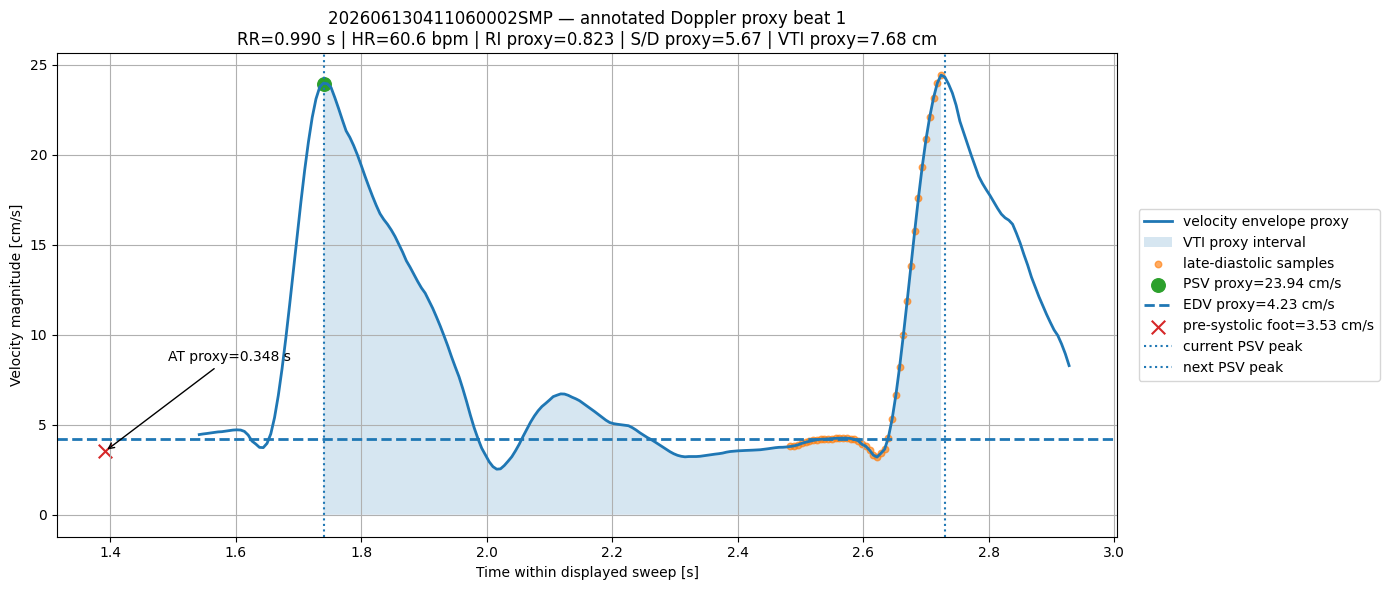

In [35]:
example_recording_id = "202606130411060002SMP"
example_beat_order = 1
example_signal_df = envelope_results[example_recording_id]["signal_df"]
example_beat_row = beat_feature_df[(beat_feature_df["recording_id"] == example_recording_id) & (beat_feature_df["beat_order"] == example_beat_order)].iloc[0]

plot_clean_annotated_hemodynamic_example_beat(
    signal_df=example_signal_df,
    beat_feature_row=example_beat_row,
    recording_id=example_recording_id,
    velocity_column="velocity_abs_cm_s",
    time_column="time_s",
    context_padding_s=0.20,
    figsize=(14, 6),
)

## Audio modality for beat timing support

This section adds Doppler audio as a second modality.

The linked AVI contains both the displayed Doppler spectrum and the Doppler audio stream. The image pipeline extracts a calibrated velocity envelope from the displayed spectrum. The audio pipeline extracts candidate beat timing from the Doppler sound.

In this notebook, audio is used for timing support and quality context. It is not used to compute PSV, EDV, RI, S/D ratio, PI, or VTI.

The comparison is performed around the same representative video frame used for image-envelope extraction. The displayed spectral sweep is treated as a short time window ending near the selected video frame.

In [36]:
def extract_audio_to_wav(
    video_path,
    output_dir,
    output_name=None,
    sample_rate=None,
    mono=True,
    overwrite=True,
):
    """
    Extract the Doppler audio stream from a linked AVI file into WAV format.

    The function uses ffmpeg to create a PCM WAV file that can be analyzed
    with the NB07 audio beat-timing pipeline.

    Parameters
    ----------
    video_path : str or pathlib.Path
        Path to the linked AVI file.

    output_dir : str or pathlib.Path
        Directory where the extracted WAV file is saved.

    output_name : str or None
        Optional output WAV file name. If None, the video stem is used.

    sample_rate : int or None
        Optional target sample rate. If None, the original audio sample rate
        is preserved.

    mono : bool
        If True, the extracted audio is converted to one channel.

    overwrite : bool
        If True, an existing WAV file is overwritten.

    Returns
    -------
    pathlib.Path
        Path to the extracted WAV file.
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if output_name is None:
        output_name = video_path.stem + "_audio.wav"

    output_path = output_dir / output_name

    command = ["ffmpeg"]

    if overwrite:
        command.append("-y")
    else:
        command.append("-n")

    command.extend(
        [
            "-i",
            str(video_path),
            "-vn",
            "-acodec",
            "pcm_s16le",
        ]
    )

    if mono:
        command.extend(["-ac", "1"])

    if sample_rate is not None:
        command.extend(["-ar", str(sample_rate)])

    command.append(str(output_path))

    result = subprocess.run(command, capture_output=True, text=True,)

    if result.returncode != 0:
        raise RuntimeError(
            "Audio extraction failed.\n"
            f"Video path: {video_path}\n"
            f"ffmpeg stderr:\n{result.stderr}"
        )

    return output_path

In [37]:
def load_audio_file(audio_path):
    """
    Load an extracted Doppler audio WAV file.

    The function returns the audio samples, sample rate, and basic duration
    metadata. Multi-channel audio is converted to mono by averaging channels.

    Parameters
    ----------
    audio_path : str or pathlib.Path
        Path to a WAV audio file.

    Returns
    -------
    dict
        Audio data and basic metadata.
    """
    audio_path = Path(audio_path)

    signal, sample_rate = sf.read(audio_path)

    if signal.ndim > 1:
        signal = np.mean(signal, axis=1)

    signal = signal.astype(np.float64)

    duration_s = len(signal) / float(sample_rate)

    return {
        "audio_path": audio_path,
        "signal": signal,
        "sample_rate": int(sample_rate),
        "duration_s": float(duration_s),
        "n_samples": int(len(signal)),
        "min_value": float(np.nanmin(signal)),
        "max_value": float(np.nanmax(signal)),
        "mean_value": float(np.nanmean(signal)),
        "std_value": float(np.nanstd(signal)),
    }

In [38]:
def compute_audio_spectral_centroid(
    signal,
    sample_rate,
    fmin=100,
    fmax=3000,
    nperseg=2048,
    noverlap=1536,
    smooth_points=15,
):
    """
    Compute a Doppler audio spectral-centroid signal.

    The function computes a spectrogram and estimates the power-weighted
    spectral centroid inside a selected Doppler audio frequency band. The
    centroid signal is used as a candidate beat-timing signal.

    Parameters
    ----------
    signal : numpy.ndarray
        Audio signal samples.

    sample_rate : int
        Audio sample rate in Hz.

    fmin : float
        Lower frequency bound for centroid calculation.

    fmax : float
        Upper frequency bound for centroid calculation.

    nperseg : int
        Spectrogram segment length.

    noverlap : int
        Spectrogram overlap.

    smooth_points : int
        Savitzky-Golay smoothing window length.

    Returns
    -------
    centroid_df : pandas.DataFrame
        Time-aligned spectral-centroid signal.

    spectrogram_debug : dict
        Spectrogram arrays and frequency-band parameters.
    """

    freqs, times, sxx = spectrogram(
        signal,
        fs=sample_rate,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
    )
    frequency_mask = (freqs >= fmin) & (freqs <= fmax)
    band_freqs = freqs[frequency_mask]
    band_power = sxx[frequency_mask, :]

    numerator = np.sum(band_freqs[:, None] * band_power, axis=0)
    denominator = np.sum(band_power, axis=0)
    centroid_hz = numerator / (denominator + 1e-12)
    if smooth_points is not None and smooth_points >= 5:
        if smooth_points % 2 == 0:
            smooth_points += 1

        if smooth_points < len(centroid_hz):
            centroid_hz = savgol_filter(
                centroid_hz,
                window_length=smooth_points,
                polyorder=2,
                mode="interp",
            )

    centroid_df = pd.DataFrame(
        {
            "audio_time_s": times.astype(float),
            "spectral_centroid_hz": centroid_hz.astype(float),
        }
    )

    spectrogram_debug = {
        "freqs": freqs,
        "times": times,
        "sxx": sxx,
        "fmin": fmin,
        "fmax": fmax,
        "frequency_mask": frequency_mask,
    }

    return centroid_df, spectrogram_debug

In [39]:
def detect_audio_beats_from_centroid(
    centroid_df,
    time_column="audio_time_s",
    centroid_column="spectral_centroid_hz",
    min_distance_s=0.5,
    prominence_hz=100,
    min_height_percentile=50,
):
    """
    Detect candidate Doppler audio beats from the spectral-centroid signal.

    The function detects peaks in the audio spectral-centroid trajectory.
    These peaks are treated as candidate beat timing markers for the Doppler
    audio modality.

    Parameters
    ----------
    centroid_df : pandas.DataFrame
        Spectral-centroid table.

    time_column : str
        Name of the audio time column.

    centroid_column : str
        Name of the spectral centroid column.

    min_distance_s : float
        Minimum distance between audio beat candidates.

    prominence_hz : float
        Minimum peak prominence in Hz.

    min_height_percentile : float
        Percentile-based minimum peak height threshold.

    Returns
    -------
    audio_beat_df : pandas.DataFrame
        Candidate audio beat table.

    detection_debug : dict
        Detection thresholds and intermediate arrays.
    """
    audio_time_s = centroid_df[time_column].to_numpy(dtype=float)
    centroid_hz = centroid_df[centroid_column].to_numpy(dtype=float)

    valid_mask = np.isfinite(audio_time_s) & np.isfinite(centroid_hz)

    audio_time_s = audio_time_s[valid_mask]
    centroid_hz = centroid_hz[valid_mask]

    if len(audio_time_s) < 5:
        return pd.DataFrame(), {
            "success": False,
            "reason": "Not enough valid centroid samples.",
        }

    dt_s = float(np.median(np.diff(audio_time_s)))

    if not np.isfinite(dt_s) or dt_s <= 0:
        return pd.DataFrame(), {
            "success": False,
            "reason": "Invalid centroid time step.",
        }

    min_distance_points = max(1, int(round(min_distance_s / dt_s)))
    height_hz = float(np.nanpercentile(centroid_hz, min_height_percentile))

    peak_indices, peak_properties = find_peaks(
        centroid_hz,
        distance=min_distance_points,
        prominence=prominence_hz,
        height=height_hz,
    )

    beat_rows = []

    for beat_order, peak_index in enumerate(peak_indices):
        beat_time_s = float(audio_time_s[peak_index])
        peak_centroid_hz = float(centroid_hz[peak_index])

        if beat_order == 0:
            rr_prev_s = np.nan
            hr_from_prev_bpm = np.nan
        else:
            rr_prev_s = beat_time_s - float(audio_time_s[peak_indices[beat_order - 1]])
            hr_from_prev_bpm = 60.0 / rr_prev_s if rr_prev_s > 0 else np.nan

        beat_rows.append(
            {
                "audio_beat_order": beat_order,
                "audio_peak_index": int(peak_index),
                "audio_beat_time_s": beat_time_s,
                "peak_centroid_hz": peak_centroid_hz,
                "audio_rr_prev_s": rr_prev_s,
                "audio_hr_from_prev_bpm": hr_from_prev_bpm,
                "audio_peak_prominence_hz": float(peak_properties["prominences"][beat_order]),
                "audio_peak_height_hz": float(peak_properties["peak_heights"][beat_order]),
            }
        )

    audio_beat_df = pd.DataFrame(beat_rows)

    detection_debug = {
        "success": True,
        "dt_s": dt_s,
        "min_distance_points": min_distance_points,
        "height_hz": height_hz,
        "prominence_hz": prominence_hz,
        "audio_time_s": audio_time_s,
        "centroid_hz": centroid_hz,
        "peak_indices": peak_indices,
        "peak_properties": peak_properties,
    }

    return audio_beat_df, detection_debug

In [40]:
def compute_audio_band_energy(
    signal,
    sample_rate,
    fmin=100,
    fmax=2000,
    nperseg=2048,
    noverlap=1536,
    smooth_points=25,
    normalize=True,
    lower_percentile=5,
    upper_percentile=95,
):
    """
    Compute spectrogram-based Doppler audio band energy.

    The function estimates the energy inside a selected Doppler audio
    frequency band. The normalized band-energy signal is used as a simple
    audio quality context signal.

    Parameters
    ----------
    signal : numpy.ndarray
        Audio signal samples.

    sample_rate : int
        Audio sample rate in Hz.

    fmin : float
        Lower frequency bound for band energy.

    fmax : float
        Upper frequency bound for band energy.

    nperseg : int
        Spectrogram segment length.

    noverlap : int
        Spectrogram overlap.

    smooth_points : int
        Uniform smoothing window size.

    normalize : bool
        If True, band energy is percentile-normalized to 0-1.

    lower_percentile : float
        Lower percentile used for normalization.

    upper_percentile : float
        Upper percentile used for normalization.

    Returns
    -------
    energy_df : pandas.DataFrame
        Time-aligned audio band-energy table.
    """
    freqs, times, sxx = spectrogram(
        signal,
        fs=sample_rate,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
    )

    frequency_mask = (freqs >= fmin) & (freqs <= fmax)
    band_energy = np.sum(sxx[frequency_mask, :], axis=0)
    band_energy = np.asarray(band_energy, dtype=np.float64)

    if smooth_points is not None and smooth_points > 1:
        band_energy = uniform_filter1d(band_energy, size=int(smooth_points))

    if normalize:
        low = float(np.nanpercentile(band_energy, lower_percentile))
        high = float(np.nanpercentile(band_energy, upper_percentile))

        if high > low:
            band_energy = (band_energy - low) / (high - low)
            band_energy = np.clip(band_energy, 0, 1)

    energy_df = pd.DataFrame(
        {
            "audio_time_s": times.astype(float),
            "audio_band_energy": band_energy.astype(float),
        }
    )

    return energy_df

In [41]:
def summarize_audio_beats(audio_beat_df, recording_id):
    """
    Summarize Doppler audio beat timing for one recording.

    The function reports detected audio beat count, mean RR interval, and
    mean HR from consecutive audio beat candidates.

    Parameters
    ----------
    audio_beat_df : pandas.DataFrame
        Candidate audio beat table.

    recording_id : str
        Recording identifier.

    Returns
    -------
    pandas.DataFrame
        One-row audio timing summary.
    """
    if audio_beat_df is None or len(audio_beat_df) == 0:
        return pd.DataFrame(
            [
                {
                    "recording_id": recording_id,
                    "n_audio_beats": 0,
                    "audio_mean_rr_s": np.nan,
                    "audio_mean_hr_bpm": np.nan,
                    "audio_rr_std_s": np.nan,
                }
            ]
        )

    rr_values = audio_beat_df["audio_rr_prev_s"].dropna().to_numpy(dtype=float)

    if len(rr_values) > 0:
        audio_mean_rr_s = float(np.nanmean(rr_values))
        audio_rr_std_s = float(np.nanstd(rr_values, ddof=1)) if len(rr_values) > 1 else np.nan
        audio_mean_hr_bpm = 60.0 / audio_mean_rr_s if audio_mean_rr_s > 0 else np.nan
    else:
        audio_mean_rr_s = np.nan
        audio_rr_std_s = np.nan
        audio_mean_hr_bpm = np.nan

    summary_df = pd.DataFrame(
        [
            {
                "recording_id": recording_id,
                "n_audio_beats": int(len(audio_beat_df)),
                "audio_mean_rr_s": audio_mean_rr_s,
                "audio_mean_hr_bpm": audio_mean_hr_bpm,
                "audio_rr_std_s": audio_rr_std_s,
            }
        ]
    )

    return summary_df

In [42]:
AUDIO_EXPORT_DIR = Path(r"D:\code\DopplerLab\audio_exports\nb07")
AUDIO_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

In [43]:
def process_nb07_linked_avi_audio(
    config_row,
    audio_export_dir,
    sample_rate=None,
    centroid_fmin=100,
    centroid_fmax=3000,
    centroid_smooth_points=15,
    audio_min_distance_s=0.5,
    audio_prominence_hz=100,
    audio_min_height_percentile=50,
    energy_fmin=100,
    energy_fmax=2000,
    energy_smooth_points=25,
):
    """
    Process Doppler audio from one NB07 linked AVI recording.

    The function extracts the audio stream from the linked AVI, computes a
    spectral-centroid timing signal, detects audio beat candidates, computes
    band-energy QC context, and returns recording-level audio timing summary.

    Parameters
    ----------
    config_row : pandas.Series or dict
        One row from the metadata-assisted PW configuration table.

    audio_export_dir : str or pathlib.Path
        Directory where extracted WAV files are saved.

    sample_rate : int or None
        Optional target audio sample rate for extraction.

    centroid_fmin : float
        Lower frequency bound for spectral-centroid calculation.

    centroid_fmax : float
        Upper frequency bound for spectral-centroid calculation.

    centroid_smooth_points : int
        Smoothing window for the centroid signal.

    audio_min_distance_s : float
        Minimum distance between audio beat candidates.

    audio_prominence_hz : float
        Minimum peak prominence for audio beat detection.

    audio_min_height_percentile : float
        Percentile threshold used as minimum audio peak height.

    energy_fmin : float
        Lower frequency bound for band-energy QC.

    energy_fmax : float
        Upper frequency bound for band-energy QC.

    energy_smooth_points : int
        Smoothing window for band-energy QC.

    Returns
    -------
    audio_result : dict
        Audio signal, centroid, energy, beat, and summary outputs.
    """
    recording_id = config_row["recording_id"]
    video_path = Path(config_row["avi_path"])

    audio_path = extract_audio_to_wav(
        video_path=video_path,
        output_dir=audio_export_dir,
        output_name=f"{recording_id}_audio.wav",
        sample_rate=sample_rate,
        mono=True,
        overwrite=True,
    )

    audio_info = load_audio_file(audio_path)

    centroid_df, spectrogram_debug = compute_audio_spectral_centroid(
        signal=audio_info["signal"],
        sample_rate=audio_info["sample_rate"],
        fmin=centroid_fmin,
        fmax=centroid_fmax,
        smooth_points=centroid_smooth_points,
    )

    audio_beat_df, audio_detection_debug = detect_audio_beats_from_centroid(
        centroid_df=centroid_df,
        min_distance_s=audio_min_distance_s,
        prominence_hz=audio_prominence_hz,
        min_height_percentile=audio_min_height_percentile,
    )

    energy_df = compute_audio_band_energy(
        signal=audio_info["signal"],
        sample_rate=audio_info["sample_rate"],
        fmin=energy_fmin,
        fmax=energy_fmax,
        smooth_points=energy_smooth_points,
        normalize=True,
    )

    audio_summary_df = summarize_audio_beats(
        audio_beat_df=audio_beat_df,
        recording_id=recording_id,
    )

    audio_result = {
        "recording_id": recording_id,
        "audio_path": audio_path,
        "audio_info": audio_info,
        "centroid_df": centroid_df,
        "spectrogram_debug": spectrogram_debug,
        "audio_beat_df": audio_beat_df,
        "audio_detection_debug": audio_detection_debug,
        "energy_df": energy_df,
        "audio_summary_df": audio_summary_df,
    }

    return audio_result

In [44]:
audio_results = {}
audio_summary_tables = []

for _, config_row in pw_config_df.iterrows():
    audio_result = process_nb07_linked_avi_audio(
        config_row=config_row,
        audio_export_dir=AUDIO_EXPORT_DIR,
        sample_rate=None,
        centroid_fmin=100,
        centroid_fmax=3000,
        centroid_smooth_points=15,
        audio_min_distance_s=0.5,
        audio_prominence_hz=100,
        audio_min_height_percentile=50,
        energy_fmin=100,
        energy_fmax=2000,
        energy_smooth_points=25,
    )

    recording_id = config_row["recording_id"]

    audio_results[recording_id] = audio_result
    audio_summary_tables.append(audio_result["audio_summary_df"])

audio_summary_df = pd.concat(audio_summary_tables, ignore_index=True)

display(audio_summary_df)

,recording_id,n_audio_beats,audio_mean_rr_s,audio_mean_hr_bpm,audio_rr_std_s
0,202606130411060002SMP,64,0.926307,64.773350,0.103978
1,202606130420260005SMP,50,0.912980,65.718884,0.177721


## Image-audio timing comparison

This section compares candidate image-derived beat timing with candidate audio-derived beat timing.

The image-derived peaks come from the calibrated velocity envelope extracted from the displayed Doppler sweep. The audio-derived peaks come from the spectral-centroid signal extracted from the Doppler audio stream.

The displayed Doppler sweep is interpreted as a short time window ending near the selected video frame. This assumption is used only for approximate image-audio timing comparison in the proof-of-concept demo.

In [45]:
def map_image_peaks_to_video_time(peak_df, signal_df, frame_info, extraction_debug, time_column="time_s"):
    """
    Map image-derived Doppler peak times to approximate video-recording time.

    The function assumes that the displayed Doppler sweep represents a short
    time history ending near the selected video frame. If a right-side ROI
    margin was removed, the right edge of the analyzed signal is treated as
    slightly earlier than the selected frame time.

    Parameters
    ----------
    peak_df : pandas.DataFrame
        Detected image peak table from the velocity envelope.

    signal_df : pandas.DataFrame
        Velocity envelope table.

    frame_info : dict
        Metadata returned by read_video_frame_at_time().

    extraction_debug : dict
        Extraction debug dictionary containing ROI margin information.

    time_column : str
        Name of the image-sweep time column.

    Returns
    -------
    image_peak_time_df : pandas.DataFrame
        Image peaks with approximate absolute video times.
    """
    if peak_df is None or len(peak_df) == 0:
        return pd.DataFrame()

    image_time_values = signal_df[time_column].to_numpy(dtype=float)
    image_signal_duration_s = float(np.nanmax(image_time_values))
    seconds_per_px = float(np.nanmedian(np.diff(image_time_values)))

    roi_info = extraction_debug.get("roi_info", {})
    right_margin_px = float(roi_info.get("right_margin_px", 0.0))
    right_margin_time_s = right_margin_px * seconds_per_px

    selected_frame_time_s = float(frame_info["actual_time_s"])
    analyzed_signal_right_edge_time_s = selected_frame_time_s - right_margin_time_s

    rows = []

    for _, peak_row in peak_df.iterrows():
        peak_time_within_sweep_s = float(peak_row["peak_time_s"])

        peak_video_time_s = (
            analyzed_signal_right_edge_time_s
            - (image_signal_duration_s - peak_time_within_sweep_s)
        )

        rows.append(
            {
                "peak_order": int(peak_row["peak_order"]),
                "image_peak_time_within_sweep_s": peak_time_within_sweep_s,
                "image_peak_video_time_s": float(peak_video_time_s),
                "psv_proxy_cm_s": float(peak_row["psv_proxy_cm_s"]),
                "selected_frame_time_s": selected_frame_time_s,
                "image_signal_duration_s": image_signal_duration_s,
                "analyzed_signal_right_edge_time_s": analyzed_signal_right_edge_time_s,
                "right_margin_time_s": right_margin_time_s,
            }
        )

    image_peak_time_df = pd.DataFrame(rows)

    return image_peak_time_df

In [46]:
def compare_image_peaks_to_nearest_audio_beats(image_peak_time_df, audio_beat_df, audio_window_padding_s=0.75):
    """
    Compare approximate image-derived beat times with nearest audio beats.

    The function performs a local nearest-neighbor comparison between
    image-derived peak times and audio-derived beat times.

    Parameters
    ----------
    image_peak_time_df : pandas.DataFrame
        Image peak timing table returned by map_image_peaks_to_video_time().

    audio_beat_df : pandas.DataFrame
        Audio beat table.

    audio_window_padding_s : float
        Padding around the image sweep window used to select audio beats.

    Returns
    -------
    comparison_df : pandas.DataFrame
        Nearest-neighbor timing comparison table.

    audio_window_df : pandas.DataFrame
        Audio beats inside the local comparison window.
    """
    if image_peak_time_df is None or len(image_peak_time_df) == 0:
        return pd.DataFrame(), pd.DataFrame()
    if audio_beat_df is None or len(audio_beat_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    image_start_s = float(image_peak_time_df["image_peak_video_time_s"].min())
    image_end_s = float(image_peak_time_df["image_peak_video_time_s"].max())

    audio_window_start_s = image_start_s - float(audio_window_padding_s)
    audio_window_end_s = image_end_s + float(audio_window_padding_s)

    audio_window_df = audio_beat_df[(audio_beat_df["audio_beat_time_s"] >= audio_window_start_s)
        & (audio_beat_df["audio_beat_time_s"] <= audio_window_end_s)].copy()

    if len(audio_window_df) == 0:
        return pd.DataFrame(), audio_window_df

    audio_times = audio_window_df["audio_beat_time_s"].to_numpy(dtype=float)

    rows = []

    for _, image_row in image_peak_time_df.iterrows():
        image_time_s = float(image_row["image_peak_video_time_s"])

        nearest_index = int(np.argmin(np.abs(audio_times - image_time_s)))
        nearest_audio_time_s = float(audio_times[nearest_index])
        delta_s = image_time_s - nearest_audio_time_s

        rows.append(
            {
                "peak_order": int(image_row["peak_order"]),
                "image_peak_video_time_s": image_time_s,
                "nearest_audio_beat_time_s": nearest_audio_time_s,
                "image_minus_audio_s": delta_s,
                "image_minus_audio_ms": delta_s * 1000.0,
                "abs_image_minus_audio_ms": abs(delta_s * 1000.0),
            }
        )

    comparison_df = pd.DataFrame(rows)

    return comparison_df, audio_window_df

In [47]:
image_audio_comparison_tables = []
image_peak_time_tables = []

for recording_id, result in envelope_results.items():
    peak_df = beat_detection_results[recording_id]["peak_df"]
    signal_df = result["signal_df"]
    frame_info = result["frame_info"]
    extraction_debug = result["extraction_debug"]

    image_peak_time_df = map_image_peaks_to_video_time(
        peak_df=peak_df,
        signal_df=signal_df,
        frame_info=frame_info,
        extraction_debug=extraction_debug,
        time_column="time_s",
    )

    audio_beat_df = audio_results[recording_id]["audio_beat_df"]

    comparison_df, audio_window_df = compare_image_peaks_to_nearest_audio_beats(
        image_peak_time_df=image_peak_time_df,
        audio_beat_df=audio_beat_df,
        audio_window_padding_s=0.75,
    )

    image_peak_time_df["recording_id"] = recording_id
    comparison_df["recording_id"] = recording_id

    image_peak_time_tables.append(image_peak_time_df)
    image_audio_comparison_tables.append(comparison_df)

image_peak_time_df = pd.concat(
    image_peak_time_tables,
    ignore_index=True,
)

image_audio_comparison_df = pd.concat(
    image_audio_comparison_tables,
    ignore_index=True,
)

display(image_peak_time_df)
display(image_audio_comparison_df)

,peak_order,image_peak_time_within_sweep_s,image_peak_video_time_s,psv_proxy_cm_s,selected_frame_time_s,image_signal_duration_s,analyzed_signal_right_edge_time_s,right_margin_time_s,recording_id
0,0,0.816,26.975333,24.217445,29.633333,3.354,29.513333,0.12,202606130411060002SMP
1,1,1.740,27.899333,23.941292,29.633333,3.354,29.513333,0.12,202606130411060002SMP
2,2,2.730,28.889333,24.227271,29.633333,3.354,29.513333,0.12,202606130411060002SMP
3,0,0.330,19.656000,23.618020,22.800000,3.354,22.680000,0.12,202606130420260005SMP
4,1,1.242,20.568000,23.544089,22.800000,3.354,22.680000,0.12,202606130420260005SMP
5,2,2.172,21.498000,23.719869,22.800000,3.354,22.680000,0.12,202606130420260005SMP
6,3,3.144,22.470000,23.427322,22.800000,3.354,22.680000,0.12,202606130420260005SMP


,peak_order,image_peak_video_time_s,nearest_audio_beat_time_s,image_minus_audio_s,image_minus_audio_ms,abs_image_minus_audio_ms,recording_id
0,0,26.975333,26.965333,0.010000,9.999977,9.999977,202606130411060002SMP
1,1,27.899333,27.877333,0.022000,21.999985,21.999985,202606130411060002SMP
2,2,28.889333,28.874667,0.014667,14.666660,14.666660,202606130411060002SMP
3,0,19.656000,19.578667,0.077333,77.333306,77.333306,202606130420260005SMP
4,1,20.568000,20.496000,0.072000,71.999981,71.999981,202606130420260005SMP
5,2,21.498000,21.450667,0.047333,47.333322,47.333322,202606130420260005SMP
6,3,22.470000,22.416000,0.054000,53.999997,53.999997,202606130420260005SMP


## Audio-image timing summary

This section summarizes the agreement between image-derived Doppler beat timing and audio-derived Doppler beat timing.

The image-derived peaks come from the calibrated velocity envelope extracted from the displayed spectral Doppler sweep.

The audio-derived peaks come from the Doppler audio spectral-centroid signal.

Audio is used as an independent timing and quality-support modality. It is not used to compute PSV, EDV, RI, S/D ratio, PI, or VTI.

In [48]:
def summarize_image_audio_timing_agreement(
    image_audio_comparison_df,
    audio_summary_df,
    recording_summary_df,
):
    """
    Summarize timing agreement between image-derived and audio-derived beats.

    The function aggregates nearest-neighbor timing differences between
    image-derived Doppler peaks and audio-derived beat candidates. It then
    combines these timing statistics with recording-level image and audio
    rhythm summaries.

    The output is intended as a compact multimodal NB07 summary. Audio is
    treated as a timing-support modality, not as a source of velocity features.

    Parameters
    ----------
    image_audio_comparison_df : pandas.DataFrame
        Table with nearest-neighbor image-audio beat timing differences.

    audio_summary_df : pandas.DataFrame
        Recording-level audio beat timing summary.

    recording_summary_df : pandas.DataFrame
        Recording-level image-derived Doppler feature summary.

    Returns
    -------
    pandas.DataFrame
        One-row-per-recording multimodal timing agreement summary.
    """
    if image_audio_comparison_df is None or len(image_audio_comparison_df) == 0:
        return pd.DataFrame()

    summary_rows = []

    for recording_id, group_df in image_audio_comparison_df.groupby("recording_id"):
        abs_delta_ms = group_df["abs_image_minus_audio_ms"].to_numpy(dtype=float)
        signed_delta_ms = group_df["image_minus_audio_ms"].to_numpy(dtype=float)

        row = {
            "recording_id": recording_id,
            "n_matched_image_audio_peaks": int(len(group_df)),
            "mean_abs_image_audio_delta_ms": float(np.nanmean(abs_delta_ms)),
            "median_abs_image_audio_delta_ms": float(np.nanmedian(abs_delta_ms)),
            "max_abs_image_audio_delta_ms": float(np.nanmax(abs_delta_ms)),
            "mean_signed_image_audio_delta_ms": float(np.nanmean(signed_delta_ms)),
        }

        summary_rows.append(row)

    timing_summary_df = pd.DataFrame(summary_rows)

    image_rhythm_columns = [
        "recording_id",
        "n_complete_beats",
        "hr_bpm_mean",
        "rr_s_mean",
        "psv_proxy_cm_s_mean",
        "edv_proxy_cm_s_mean",
        "ri_proxy_mean",
        "vti_proxy_cm_mean",
    ]

    available_image_columns = [
        column
        for column in image_rhythm_columns
        if column in recording_summary_df.columns
    ]

    image_summary_small_df = recording_summary_df[available_image_columns].copy()

    audio_summary_small_df = audio_summary_df[
        [
            "recording_id",
            "n_audio_beats",
            "audio_mean_rr_s",
            "audio_mean_hr_bpm",
            "audio_rr_std_s",
        ]
    ].copy()

    multimodal_summary_df = timing_summary_df.merge(image_summary_small_df, on="recording_id", how="left")
    multimodal_summary_df = multimodal_summary_df.merge(audio_summary_small_df, on="recording_id", how="left")

    if {
        "hr_bpm_mean",
        "audio_mean_hr_bpm",
    }.issubset(multimodal_summary_df.columns):
        multimodal_summary_df["image_minus_audio_hr_bpm"] = (
            multimodal_summary_df["hr_bpm_mean"]
            - multimodal_summary_df["audio_mean_hr_bpm"]
        )

    if {
        "rr_s_mean",
        "audio_mean_rr_s",
    }.issubset(multimodal_summary_df.columns):
        multimodal_summary_df["image_minus_audio_rr_s"] = (
            multimodal_summary_df["rr_s_mean"]
            - multimodal_summary_df["audio_mean_rr_s"]
        )

    return multimodal_summary_df.sort_values("recording_id").reset_index(drop=True)

In [49]:
image_audio_timing_summary_df = summarize_image_audio_timing_agreement(
    image_audio_comparison_df=image_audio_comparison_df,
    audio_summary_df=audio_summary_df,
    recording_summary_df=recording_summary_df,
)

display(image_audio_timing_summary_df)

,recording_id,n_matched_image_audio_peaks,mean_abs_image_audio_delta_ms,median_abs_image_audio_delta_ms,max_abs_image_audio_delta_ms,mean_signed_image_audio_delta_ms,n_complete_beats,hr_bpm_mean,rr_s_mean,psv_proxy_cm_s_mean,edv_proxy_cm_s_mean,ri_proxy_mean,vti_proxy_cm_mean,n_audio_beats,audio_mean_rr_s,audio_mean_hr_bpm,audio_rr_std_s,image_minus_audio_hr_bpm,image_minus_audio_rr_s
0,202606130411060002SMP,3,15.555541,14.666660,21.999985,15.555541,2,62.770562,0.957,24.079368,4.423152,0.816350,7.538831,64,0.926307,64.773350,0.103978,-2.002788,0.030693
1,202606130420260005SMP,4,62.666651,62.999989,77.333306,62.666651,3,64.011332,0.938,23.627326,16.230652,0.313215,13.617022,50,0.912980,65.718884,0.177721,-1.707552,0.025020


In [50]:
def build_clean_image_audio_timing_display_table(image_audio_timing_summary_df):
    """
    Build a compact display table for image-audio timing agreement.

    The function selects and rounds key multimodal timing columns for final
    NB07 notebook presentation.

    Parameters
    ----------
    image_audio_timing_summary_df : pandas.DataFrame
        Multimodal timing agreement summary table.

    Returns
    -------
    pandas.DataFrame
        Clean display table.
    """
    display_columns = [
        "recording_id",
        "n_matched_image_audio_peaks",
        "mean_abs_image_audio_delta_ms",
        "median_abs_image_audio_delta_ms",
        "max_abs_image_audio_delta_ms",
        "hr_bpm_mean",
        "audio_mean_hr_bpm",
        "image_minus_audio_hr_bpm",
        "rr_s_mean",
        "audio_mean_rr_s",
        "image_minus_audio_rr_s",
        "n_audio_beats",
    ]

    available_columns = [column for column in display_columns if column in image_audio_timing_summary_df.columns]
    clean_df = image_audio_timing_summary_df[available_columns].copy()
    rounding_map = {
        "mean_abs_image_audio_delta_ms": 1,
        "median_abs_image_audio_delta_ms": 1,
        "max_abs_image_audio_delta_ms": 1,
        "hr_bpm_mean": 1,
        "audio_mean_hr_bpm": 1,
        "image_minus_audio_hr_bpm": 1,
        "rr_s_mean": 3,
        "audio_mean_rr_s": 3,
        "image_minus_audio_rr_s": 3,
    }

    for column, decimals in rounding_map.items():
        if column in clean_df.columns:
            clean_df[column] = clean_df[column].round(decimals)

    return clean_df

In [51]:
clean_image_audio_timing_display_df = build_clean_image_audio_timing_display_table(
    image_audio_timing_summary_df=image_audio_timing_summary_df,
)

display(clean_image_audio_timing_display_df)

,recording_id,n_matched_image_audio_peaks,mean_abs_image_audio_delta_ms,median_abs_image_audio_delta_ms,max_abs_image_audio_delta_ms,hr_bpm_mean,audio_mean_hr_bpm,image_minus_audio_hr_bpm,rr_s_mean,audio_mean_rr_s,image_minus_audio_rr_s,n_audio_beats
0,202606130411060002SMP,3,15.6,14.7,22.0,62.8,64.8,-2.0,0.957,0.926,0.031,64
1,202606130420260005SMP,4,62.7,63.0,77.3,64.0,65.7,-1.7,0.938,0.913,0.025,50


In [52]:
def plot_image_audio_timing_alignment(
    recording_id,
    image_peak_time_df,
    audio_results,
    image_audio_comparison_df,
    window_padding_s=0.75,
    figsize=(14, 5),
):
    """
    Plot local timing alignment between image-derived and audio-derived beats.

    The function displays the audio spectral-centroid signal around the
    selected image-derived Doppler sweep and overlays image-derived peak
    times and audio-derived beat candidates.

    This plot is intended to show that Doppler audio provides independent
    beat-timing support for the image-derived velocity envelope.

    Parameters
    ----------
    recording_id : str
        Recording identifier to plot.

    image_peak_time_df : pandas.DataFrame
        Image-derived peak timing table.

    audio_results : dict
        Audio result dictionary keyed by recording ID.

    image_audio_comparison_df : pandas.DataFrame
        Image-audio nearest-neighbor comparison table.

    window_padding_s : float
        Padding around the image-derived peak time range.

    figsize : tuple
        Matplotlib figure size.

    Returns
    -------
    None
        The function displays the plot.
    """
    image_df = image_peak_time_df[image_peak_time_df["recording_id"] == recording_id].copy()
    comparison_df = image_audio_comparison_df[image_audio_comparison_df["recording_id"] == recording_id].copy()

    if len(image_df) == 0:
        raise ValueError(f"No image peak timing rows found for recording: {recording_id}")
    if recording_id not in audio_results:
        raise ValueError(f"No audio result found for recording: {recording_id}")

    centroid_df = audio_results[recording_id]["centroid_df"]
    audio_beat_df = audio_results[recording_id]["audio_beat_df"]
    local_start_s = float(image_df["image_peak_video_time_s"].min()) - float(window_padding_s)
    local_end_s = float(image_df["image_peak_video_time_s"].max()) + float(window_padding_s)

    centroid_local_df = centroid_df[
        (centroid_df["audio_time_s"] >= local_start_s)
        & (centroid_df["audio_time_s"] <= local_end_s)
    ].copy()

    audio_beat_local_df = audio_beat_df[
        (audio_beat_df["audio_beat_time_s"] >= local_start_s)
        & (audio_beat_df["audio_beat_time_s"] <= local_end_s)
    ].copy()

    plt.figure(figsize=figsize)

    plt.plot(
        centroid_local_df["audio_time_s"],
        centroid_local_df["spectral_centroid_hz"],
        linewidth=2,
        label="audio spectral centroid",
    )

    if len(audio_beat_local_df) > 0:
        plt.scatter(
            audio_beat_local_df["audio_beat_time_s"],
            audio_beat_local_df["peak_centroid_hz"],
            s=70,
            marker="o",
            label="audio beat candidates",
        )

    y_min = float(np.nanmin(centroid_local_df["spectral_centroid_hz"]))
    y_max = float(np.nanmax(centroid_local_df["spectral_centroid_hz"]))
    y_text = y_max - 0.08 * (y_max - y_min)

    for _, image_row in image_df.iterrows():
        image_time_s = float(image_row["image_peak_video_time_s"])

        plt.axvline(
            image_time_s,
            linestyle="--",
            linewidth=1.5,
            label="image-derived PSV peak" if image_row.name == image_df.index[0] else None,
        )

        plt.text(
            image_time_s,
            y_text,
            f"img {int(image_row['peak_order'])}",
            rotation=90,
            va="top",
            ha="right",
            fontsize=9,
        )

    if len(comparison_df) > 0:
        mean_abs_ms = float(np.nanmean(comparison_df["abs_image_minus_audio_ms"]))
        max_abs_ms = float(np.nanmax(comparison_df["abs_image_minus_audio_ms"]))
        timing_text = f"mean |image-audio|={mean_abs_ms:.1f} ms, max={max_abs_ms:.1f} ms"
    else:
        timing_text = "no image-audio comparison rows"

    plt.title(f"{recording_id} — local Doppler audio-image timing alignment\n{timing_text}")
    plt.xlabel("Video/audio time [s]")
    plt.ylabel("Audio spectral centroid [Hz]")
    plt.grid(True)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

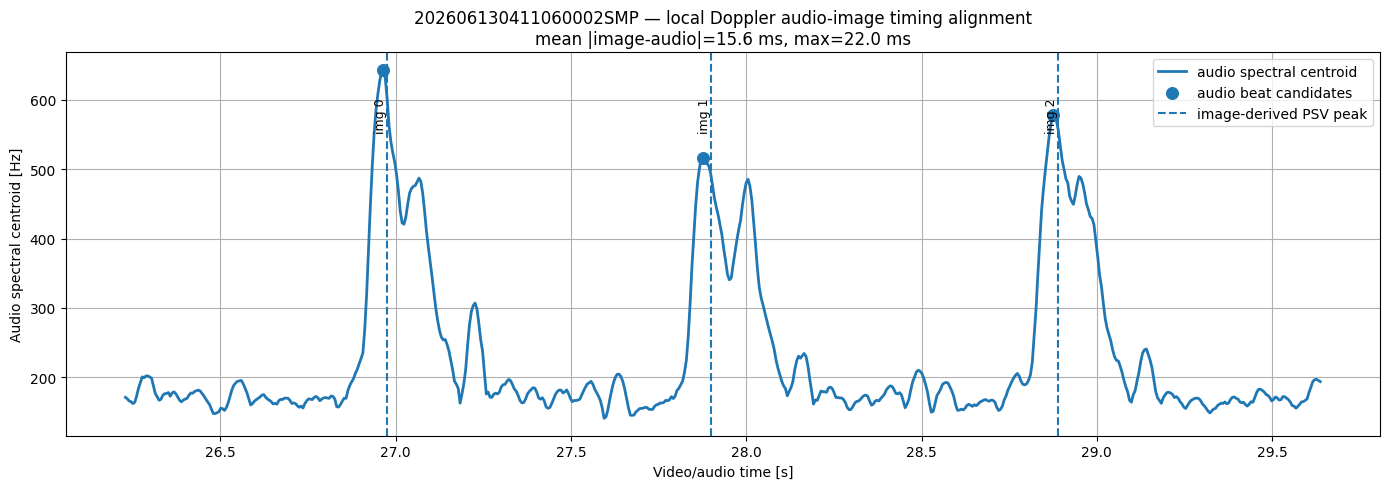

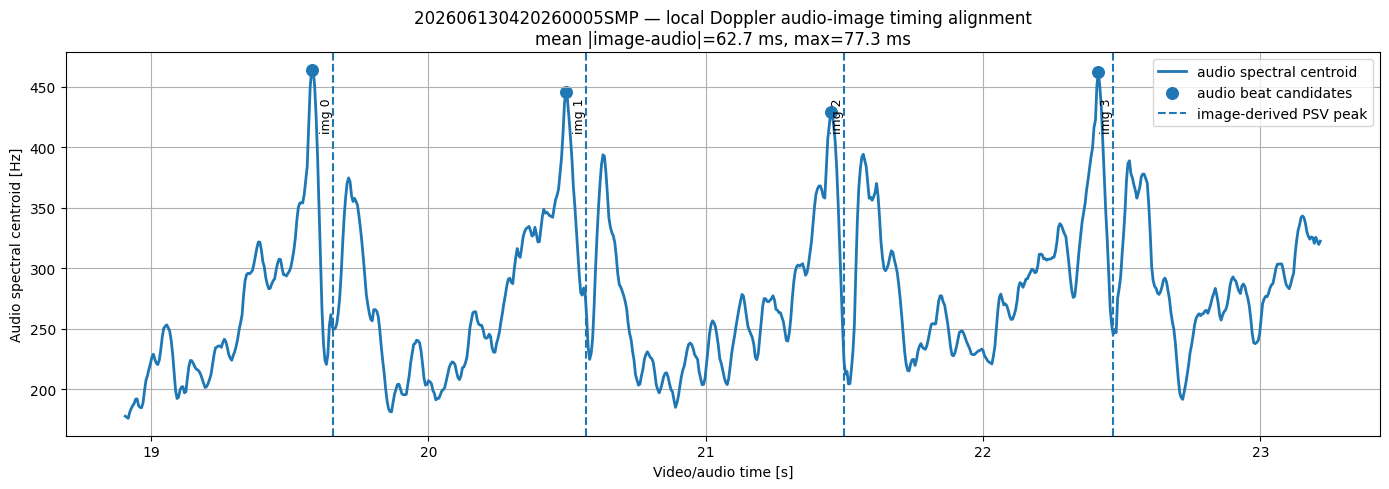

In [53]:
for recording_id in SELECTED_RECORDING_IDS:
    plot_image_audio_timing_alignment(
        recording_id=recording_id,
        image_peak_time_df=image_peak_time_df,
        audio_results=audio_results,
        image_audio_comparison_df=image_audio_comparison_df,
        window_padding_s=0.75,
        figsize=(14, 5),
    )

## Limitations and next steps

This notebook demonstrates a metadata-assisted, image-audio proof of concept on two selected PW Doppler video recordings.

The demonstrated outputs are:

* metadata-derived PW spectral ROI
* metadata-derived baseline
* metadata-derived time and velocity scale
* candidate velocity envelope from linked AVI image frames
* candidate image-derived beat segmentation
* beat-level Doppler proxy features
* recording-level Doppler proxy summary
* Doppler audio beat timing
* image-audio timing comparison
* annotated example beat

The linked AVI video is used as the displayed Doppler image source and Doppler audio source. The native Mindray export is used as metadata support for ROI position, baseline position, time scale, and velocity scale.

The image-derived envelope is extracted from the displayed Doppler spectrum in the linked AVI. It is not yet a validated clinical maximum velocity envelope.

The audio-derived signal is extracted from the Doppler audio stream. In this notebook, audio is used as an independent timing-support and quality-context modality. Audio is not used to compute PSV, EDV, RI, S/D ratio, PI, or VTI.

The beat-level image features are interpreted as signal-processing proxy features. This is especially important for:

* EDV proxy
* RI proxy
* S/D ratio proxy
* PI proxy
* VTI proxy
* acceleration time proxy
* systolic upslope proxy

The first selected recording shows a cleaner Doppler spectrum and stronger image-audio agreement. The image-derived beat timing aligns with audio-derived beat timing within approximately 10–22 ms for the selected displayed sweep.

The second selected recording shows a higher noise floor near the baseline. This likely increases the EDV proxy and reduces the RI proxy. The audio-image timing agreement is weaker than in the first recording, but the image-derived and audio-derived rhythm estimates remain similar.

The approximate image-audio timing comparison assumes that the displayed Doppler sweep represents a short time window ending near the selected video frame. This assumption is sufficient for the proof-of-concept timing check, but exact synchronization would require a dedicated validation step.

This notebook does not estimate:

* absolute volumetric blood flow
* stroke volume
* blood pressure
* clinical diagnosis
* clinical-grade Doppler measurements
* native-file-only Doppler decoding

Absolute flow estimation would require reliable vessel diameter or cross-sectional area, Doppler angle correction, validated mean velocity estimation, and controlled acquisition protocol.

What is demonstrated:

* native metadata can reduce manual Doppler setup
* linked AVI can provide a usable displayed spectral signal
* linked AVI audio can provide independent beat timing support
* a calibrated velocity-time proxy signal can be extracted
* candidate beat cycles can be detected
* structured beat-level and recording-level proxy features can be produced
* image-derived and audio-derived beat timing can be compared

What remains future work:

* metadata-assisted batch processing
* automatic recording quality grading
* more robust envelope extraction
* more robust EDV and acceleration-foot detection
* full audio-image synchronization validation
* comparison against manual Doppler tracing
* validation across more recordings, vessels, and acquisition conditions

This notebook should be interpreted as a clean technical feasibility demo, not as a final clinical Doppler measurement pipeline.
